<div class="alert alert-block alert-success">
<h1> DATA MINING - PROJECT </h1>
<h2> Group 19 </h2>
<h3> 20225/2026 </h3>

Student Name - António Parafita <br>
Student id - 20250363 <br>

Student Name - Diogo Montenegro <br>
Student id - 20250491 <br>

Student Name - Francisco <br>
Student id - 20250482 <br>

## **Index**<br>



<a class="anchor" id="1st-bullet">    </a>
# 1. Imports

<a class="anchor" id="2st-bullet">    </a>
## 1.1 Import libraries

In [303]:
import sqlite3
import os
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from itertools import product

#maps
import folium
from folium.plugins import MarkerCluster
from folium.plugins import HeatMap
from IPython.display import IFrame

from ydata_profiling import ProfileReport

# for better resolution plots
%config InlineBackend.figure_format = 'retina' # optionally, you can change 'svg' to 'retina'

# Setting seaborn style
sns.set_style("ticks")

## Functions

In [304]:
def detect_outliers_iqr(data, threshold=0.01):
    """
    Detects outliers in numerical columns using the Interquartile Range (IQR) method
    and optionally reports columns where the percentage of outliers exceeds a threshold.
    A boxplot highlighting the outliers is also generated for each column.

    Parameters:
        data (DataFrame): 
            The input dataset containing numerical variables.
    """
    outlier_summary = []
    for col in data.select_dtypes(include=['float64', 'int64']).columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Identify outliers
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)][col]
        n_outliers = len(outliers)
        pct_outliers = 100 * n_outliers / len(data)
        # Print summary
        print(f"Column: {col} - Number of Outliers: {n_outliers}")
        print(f"Column: {col} - % of Outliers: {pct_outliers:.2f}%\n")
        # Add to list if exceeds threshold
        if pct_outliers > threshold * 100:
            outlier_summary.append((col, n_outliers, pct_outliers))
        # Plot boxplot
        plt.figure(figsize=(8, 5))
        sns.boxplot(x=data[col], color='orange')
        sns.stripplot(x=outliers, color='red', size=4, label='Outliers')
        plt.title(f'Boxplot with Outliers for {col}', fontsize=14)
        plt.legend()
        plt.show()
    return pd.DataFrame(outlier_summary, columns=['Column', 'Num_Outliers', 'Pct_Outliers'])

<a class="anchor" id="3st-bullet">    </a>
## 1.2 Import Data

In [305]:
customers = pd.read_csv('data/DM_AIAI_CustomerDB.csv', index_col = 0)
flights = pd.read_csv('data/DM_AIAI_FlightsDB.csv')

In [306]:
df_c = customers.copy()

In [307]:
df_f = flights.copy()

## 2 Data Preprocessing


### 2.1 Data types

**Customers dataset**

In [308]:
df_c.sample(10)

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
5090,310853,Raymonde,Kreamalmeyer,Raymonde Kreamalmeyer,Canada,Ontario,Toronto,43.653225,-79.383186,P2T 6G3,female,Bachelor,Rural,98278.0,Married,Nova,7/26/2015,NaN,3439.09,Standard
16074,607588,Simone,Maclean,Simone Maclean,Canada,Ontario,Toronto,43.653225,-79.383186,P5S 6R4,male,Bachelor,Urban,37050.0,Married,Star,3/24/2021,NaN,12885.79,2021 Promotion
16231,143389,Rolf,Ganga,Rolf Ganga,Canada,Nova Scotia,Halifax,44.648766,-63.575237,B3C 2M8,female,Bachelor,Suburban,56457.0,Single,Star,2/10/2019,NaN,14413.38,Standard
9637,933208,Jaqueline,Alquicira,Jaqueline Alquicira,Canada,Ontario,Toronto,43.653225,-79.383186,P1J 8T7,male,College,Urban,0.0,Single,Nova,7/6/2018,NaN,22337.16,Standard
10956,200744,Alesha,Durtschi,Alesha Durtschi,Canada,Manitoba,Winnipeg,49.895138,-97.138374,R2C 0M5,female,Bachelor,Rural,41247.0,Divorced,Star,10/4/2019,NaN,2521.68,Standard
5581,653354,Norman,Whitty,Norman Whitty,Canada,Ontario,Toronto,43.653225,-79.383186,P1L 8X8,male,Bachelor,Urban,37384.0,Married,Nova,8/22/2020,NaN,4014.45,Standard
6695,741700,Ela,Trueblood,Ela Trueblood,Canada,Alberta,Edmonton,53.544388,-113.490930,T9G 1W3,female,College,Rural,0.0,Single,Nova,9/14/2015,NaN,5435.77,Standard
11577,918341,Frederica,Schegetz,Frederica Schegetz,Canada,Ontario,Kingston,44.231171,-76.485954,M9K 2P4,male,College,Urban,0.0,Divorced,Star,7/16/2015,NaN,2659.71,Standard
10976,401350,Tawanna,Augustson,Tawanna Augustson,Canada,Alberta,Banff,51.178398,-115.570800,T4V 1D4,male,Bachelor,Urban,80744.0,Married,Star,9/29/2021,5/29/2019,2527.65,Standard
13037,289354,Maryetta,Thibault,Maryetta Thibault,Canada,Ontario,Kingston,44.231171,-76.485954,M9K 2P4,female,Doctor,Urban,12261.0,Divorced,Star,11/25/2015,NaN,4643.41,Standard


In [309]:
df_c.dtypes

Loyalty#                     int64
First Name                  object
Last Name                   object
Customer Name               object
Country                     object
Province or State           object
City                        object
Latitude                   float64
Longitude                  float64
Postal code                 object
Gender                      object
Education                   object
Location Code               object
Income                     float64
Marital Status              object
LoyaltyStatus               object
EnrollmentDateOpening       object
CancellationDate            object
Customer Lifetime Value    float64
EnrollmentType              object
dtype: object

In [310]:
df_f.sample(10)

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
38570,437407,2020,4,4/1/2020,4.0,4.0,24302.0,2430.00,0.0,0.0
591128,976695,2019,11,11/1/2019,7.2,0.9,20574.9,2057.49,0.0,0.0
501336,696128,2019,6,6/1/2019,13.5,3.6,10264.5,1026.45,0.0,0.0
499817,615201,2019,6,6/1/2019,6.3,6.3,12244.5,1224.45,0.0,0.0
435664,796990,2019,2,2/1/2019,0.0,0.0,0.0,0.00,0.0,0.0
271812,989256,2021,1,1/1/2021,9.0,2.0,19746.0,1974.00,0.0,0.0
995,942083,2020,6,6/1/2020,0.0,0.0,0.0,0.00,0.0,0.0
441836,229436,2019,3,3/1/2019,0.0,0.0,0.0,0.00,0.0,0.0
504576,867446,2019,6,6/1/2019,13.5,0.0,5457.6,545.76,0.0,0.0
100459,309480,2021,11,11/1/2021,3.0,0.0,5005.0,500.00,0.0,0.0


In [311]:
df_f.dtypes

Loyalty#                      int64
Year                          int64
Month                         int64
YearMonthDate                object
NumFlights                  float64
NumFlightsWithCompanions    float64
DistanceKM                  float64
PointsAccumulated           float64
PointsRedeemed              float64
DollarCostPointsRedeemed    float64
dtype: object

**Set 'EnrollmentDateOpening', 'CancellationDate' & 'YearMonthDate' type to *datetime***

In [312]:
df_c['EnrollmentDateOpening'] = pd.to_datetime(
    df_c['EnrollmentDateOpening'],
    errors='coerce'
)

df_c['CancellationDate'] = pd.to_datetime(
    df_c['CancellationDate'],
    errors='coerce'
)

df_f['YearMonthDate'] = pd.to_datetime(
    df_f['YearMonthDate'],
    errors='coerce'
)

**Changing data type of numFlights & numFlightsWithCompanions to int**

In [313]:
df_f['NumFlights'] = df_f['NumFlights'].astype(int)
df_f['NumFlightsWithCompanions'] = df_f['NumFlightsWithCompanions'].astype(int)

**Changing income to int**

In [314]:
df_c["Income"] = df_c["Income"].astype("Int64")

Lets create 2 lists for each df, to store the numerical and categorical features separatly.

In [315]:
c_metric = ['Income', 'Customer Lifetime Value','Latitude','Longitude']
c_categ = ['First Name', 'Last Name','Customer Name','Country', 'Province or State', 'City','Postal code','Gender','Education','Location Code','Marital Status',
          'LoyaltyStatus','EnrollmentType' ]
f_metric = ['Year','Month','NumFlights','NumFlightsWithCompanions','DistanceKM','PointsAccumulated','PointsRedeemed','DollarCostPointsRedeemed']

## Duplicates

In [316]:
# replace "" by nans
df_c.replace("", np.nan, inplace=True)
# count of missing values
df_c.isna().sum()

Loyalty#                       0
First Name                     0
Last Name                      0
Customer Name                  0
Country                        0
Province or State              0
City                           0
Latitude                       0
Longitude                      0
Postal code                    0
Gender                         0
Education                      0
Location Code                  0
Income                        20
Marital Status                 0
LoyaltyStatus                  0
EnrollmentDateOpening          0
CancellationDate           14613
Customer Lifetime Value       20
EnrollmentType                 0
dtype: int64

In [317]:
# replace "" by nans
df_f.replace("", np.nan, inplace=True)

# count of missing values
df_f.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
dtype: int64

**Checking for duplicates and dropping them**

In [318]:
df_c.duplicated().sum()

0

In [319]:
df_f.duplicated().sum()

2903

In [320]:
df_f = df_f.drop_duplicates()
df_f.duplicated().sum()

0

— We should drop them because a customer shouldn't have the same month of the same year registered more than once

**Checking if Loyalty# has repeated values**

In [321]:
# How many Loyalty# have duplicates?
print(df_c['Loyalty#'].value_counts()[df_c['Loyalty#'].value_counts() > 1].size)
print(df_f['Loyalty#'].value_counts()[df_f['Loyalty#'].value_counts() > 1].size)

163
16737


In [322]:
#checking if there are extra ids in flights dataset
extra_ids = set(df_f['Loyalty#']) - set(df_c['Loyalty#'])
print( len(extra_ids))

0


In [323]:
#checking how many customer ids don't have flights
ids_without_flights = set(df_c['Loyalty#']) - set(df_f['Loyalty#'])
print( len(ids_without_flights))


20


In [324]:
# 1) Find problematic Loyalty# values in the df_c (appear more than once)
dupe_ids_cust = (
    df_c['Loyalty#']
    .value_counts()
    .loc[lambda s: s > 1]
    .index
)

# 2) Completely remove those values from both datasets
df_c = df_c[~df_c['Loyalty#'].isin(dupe_ids_cust)].copy()
df_f = df_f[~df_f['Loyalty#'].isin(dupe_ids_cust)].copy()

**Checking zeros and negative values**

In [325]:
# Check for zeros in customer dataset
(df_c == 0).sum()

Loyalty#                      0
First Name                    0
Last Name                     0
Customer Name                 0
Country                       0
Province or State             0
City                          0
Latitude                      0
Longitude                     0
Postal code                   0
Gender                        0
Education                     0
Location Code                 0
Income                     4198
Marital Status                0
LoyaltyStatus                 0
EnrollmentDateOpening         0
CancellationDate              0
Customer Lifetime Value       0
EnrollmentType                0
dtype: Int64

In [326]:
# Check for negative values in customer dataset
(df_c.select_dtypes(include=['number']) < 0).sum()

Loyalty#                       0
Latitude                       0
Longitude                  16594
Income                         0
Customer Lifetime Value        0
dtype: Int64

In [327]:
# Check for zeros in flights dataset
(df_f == 0).sum()

Loyalty#                         0
Year                             0
Month                            0
YearMonthDate                    0
NumFlights                  303071
NumFlightsWithCompanions    447294
DistanceKM                  291496
PointsAccumulated           291496
PointsRedeemed              561780
DollarCostPointsRedeemed    561780
dtype: int64

In [328]:
# Check for negative values in flights dataset
(df_f.select_dtypes(include=['number']) < 0).sum()

Loyalty#                    0
Year                        0
Month                       0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
dtype: int64

## Feature Creation

**"Days_sub" - number of days subscribed in program**

In [329]:
# Converte to datetime
df_c["EnrollmentDateOpening"] = pd.to_datetime(df_c["EnrollmentDateOpening"], errors="coerce")
df_c["CancellationDate"] = pd.to_datetime(df_c["CancellationDate"], errors="coerce")

# Assume that "today" is the last recent date found in dataset
max_date = max(df_c["EnrollmentDateOpening"].max(), df_c["CancellationDate"].max())
print(f"Most recent date extracted: {max_date}\n")

# Compute difference in days
df_c["Days_sub"] = (
    df_c["CancellationDate"].fillna(max_date) - df_c["EnrollmentDateOpening"]
).dt.days

# If negative value, assume there was a switch of dates 
df_c["Days_sub"] = df_c["Days_sub"].abs()
# Description (no negative value)
print(df_c["Days_sub"].describe())

Most recent date extracted: 2021-12-30 00:00:00

count    16594.000000
mean      1098.976076
std        737.900363
min          0.000000
25%        389.000000
50%       1015.000000
75%       1744.000000
max       2465.000000
Name: Days_sub, dtype: float64


In [330]:
c_metric.append('Days_sub')


Since we've created this new feature, we can now drop both **"EnrollmentDateOpening"** and **"CancellationDate"** since having this have the same meaning.

In [331]:
df_c = df_c.drop(['EnrollmentDateOpening', 'CancellationDate'], axis=1)

***AvgFlightDistance_month* — Average distance per flight taken by a customer in a specific month**

In [332]:
df_f['AvgFlightDistance_month'] = np.where(
    df_f['NumFlights'] > 0,
    df_f['DistanceKM'] / df_f['NumFlights'],
    0
)

df_f.sample(10)

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,AvgFlightDistance_month
172027,365596,2021,10,2021-10-01,0,0,0.0,0.00,0.0,0.0,0.000000
163882,437407,2021,12,2021-12-01,0,0,0.0,0.00,0.0,0.0,0.000000
112662,669028,2021,6,2021-06-01,14,0,30591.0,3059.00,0.0,0.0,2185.071429
422437,995333,2019,1,2019-01-01,9,0,15715.8,1571.58,0.0,0.0,1746.200000
421442,942779,2019,1,2019-01-01,0,0,0.0,0.00,0.0,0.0,0.000000
110723,159533,2021,12,2021-12-01,11,0,9277.0,927.00,0.0,0.0,843.363636
480279,476258,2019,5,2019-05-01,0,0,0.0,0.00,0.0,0.0,0.000000
440336,148810,2019,3,2019-03-01,0,0,0.0,0.00,0.0,0.0,0.000000
520798,832301,2019,7,2019-07-01,9,0,27495.9,2749.59,0.0,0.0,3055.100000
415705,636017,2019,1,2019-01-01,0,0,0.0,0.00,0.0,0.0,0.000000


In [333]:
f_metric.append('AvgFlightDistance_month')


## Dealing with outliers

<h1>df_c

In [359]:
df_c.columns

Index(['Loyalty#', 'First Name', 'Last Name', 'Customer Name', 'Country',
       'Province or State', 'City', 'Latitude', 'Longitude', 'Postal code',
       'Gender', 'Education', 'Location Code', 'Income', 'Marital Status',
       'LoyaltyStatus', 'Customer Lifetime Value', 'EnrollmentType',
       'Days_sub'],
      dtype='object')

In [334]:
df_c_metric = ['Customer Lifetime Value', 'Income', 'Days_sub']

Column: Customer Lifetime Value - Number of Outliers: 1460
Column: Customer Lifetime Value - % of Outliers: 8.80%



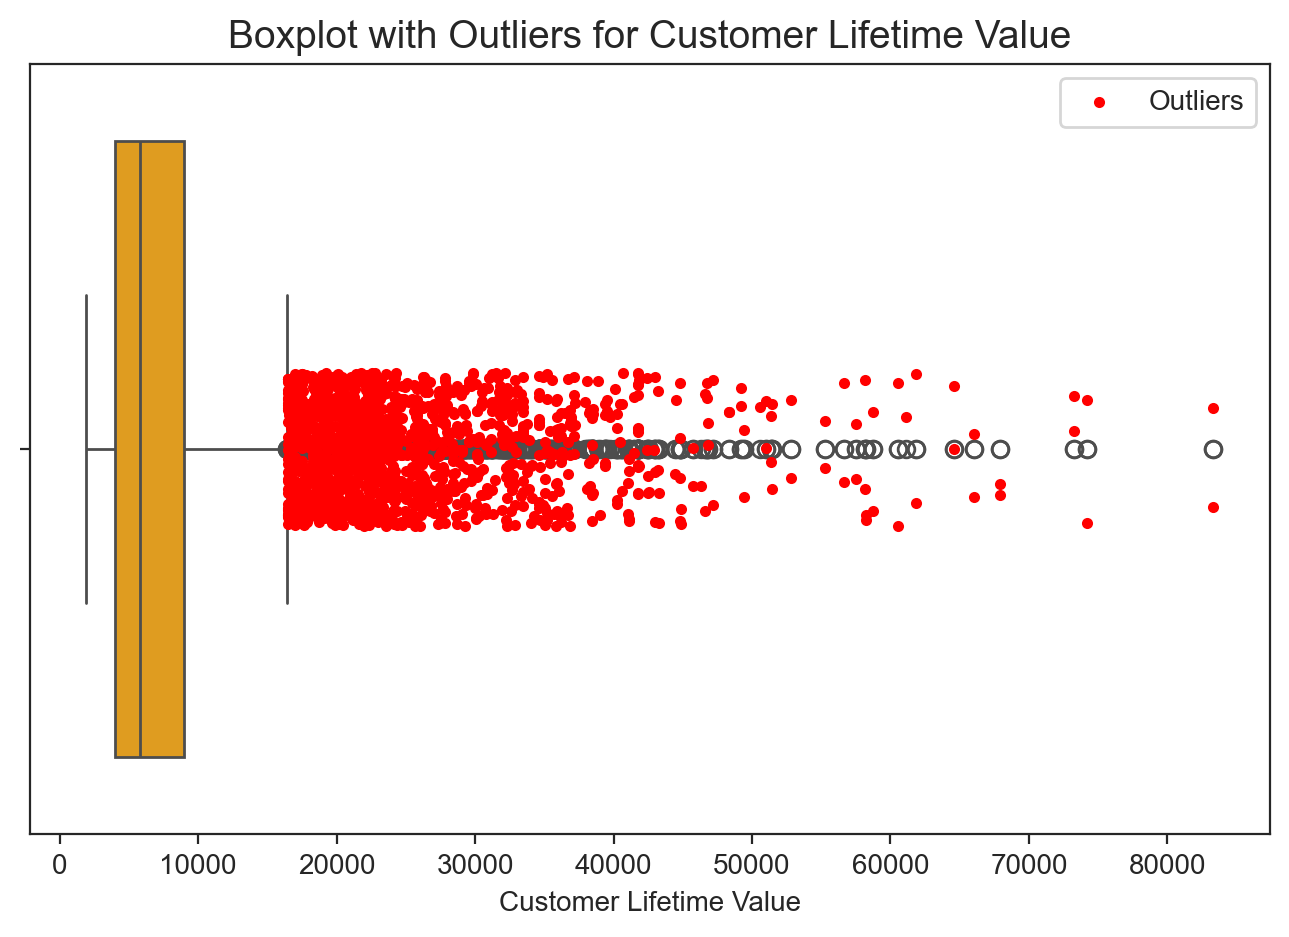

Column: Income - Number of Outliers: 0
Column: Income - % of Outliers: 0.00%



/var/folders/vb/yhn0331x30n4j9b7wy_v2chm0000gn/T/ipykernel_10405/2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


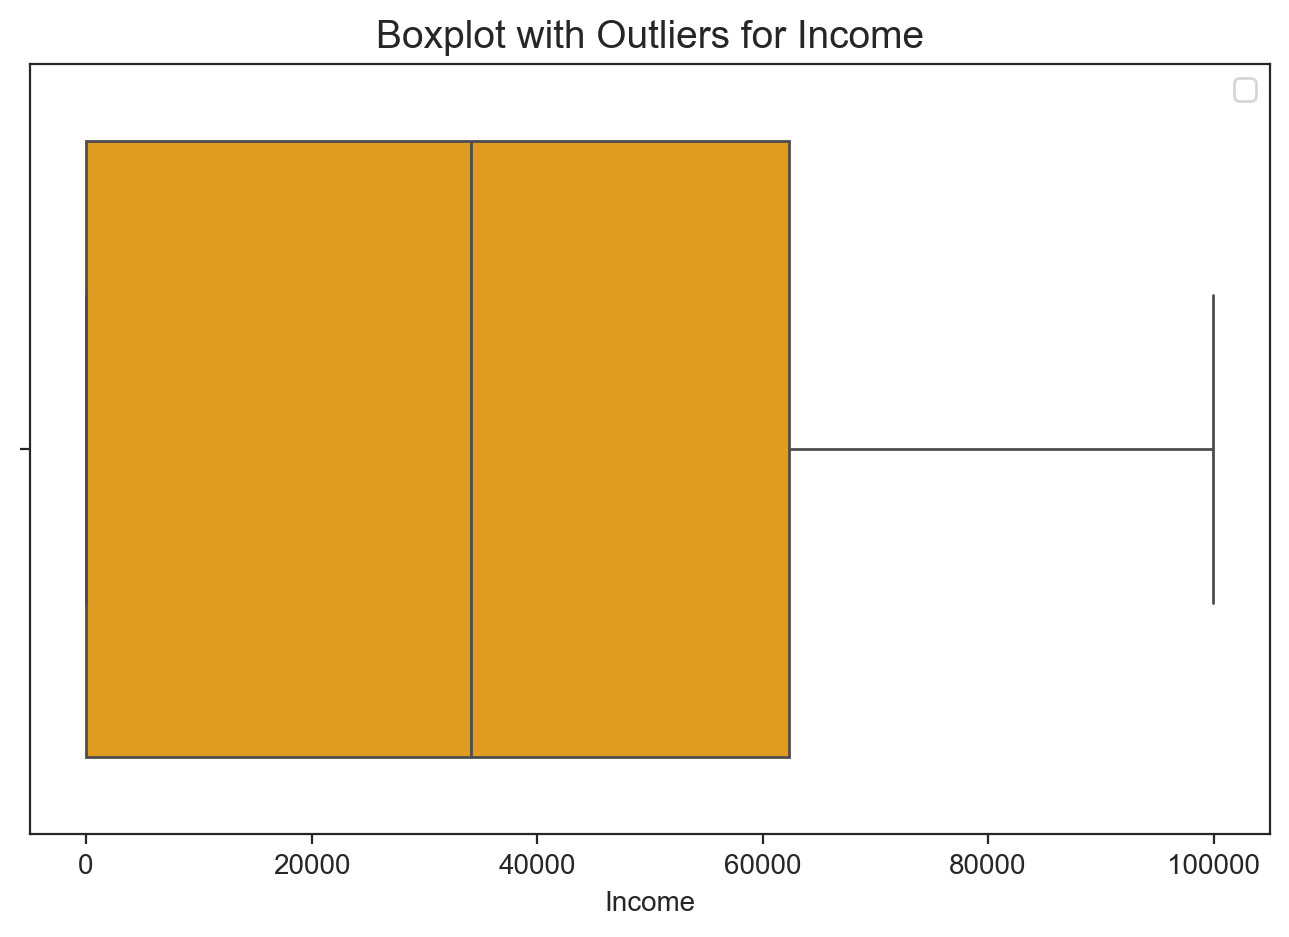

Column: Days_sub - Number of Outliers: 0
Column: Days_sub - % of Outliers: 0.00%



/var/folders/vb/yhn0331x30n4j9b7wy_v2chm0000gn/T/ipykernel_10405/2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


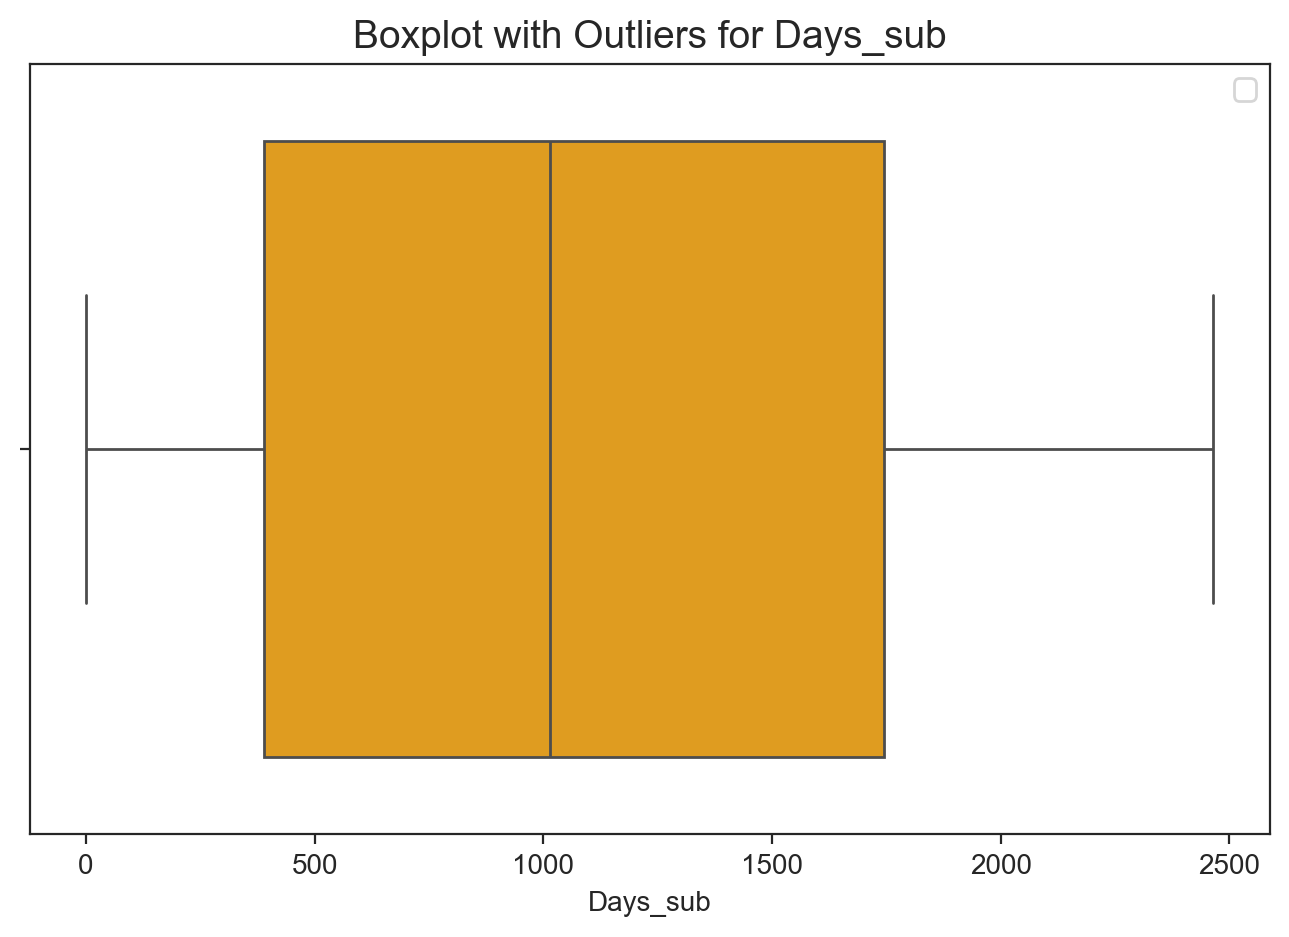

,Column,Num_Outliers,Pct_Outliers
0,Customer Lifetime Value,1460,8.798361


In [335]:
detect_outliers_iqr(df_c[df_c_metric], 0.001)

We only observe missing values for **Customer Lifetime Value**

We won't take action on this, since they're all from the same city.

In [367]:
df_c.loc[df_c['Customer Lifetime Value']>50000]

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,Customer Lifetime Value,EnrollmentType,Days_sub
4149,364710,Estella,Hymes,Estella Hymes,Canada,Quebec,Tremblant,46.118462,-74.596184,H5Y 2S9,female,Bachelor,Urban,25167.0,Married,Aurora,51016.07,2021 Promotion,270.0
4150,566374,Heriberto,Teixeira,Heriberto Teixeira,Canada,New Brunswick,Moncton,46.087818,-64.778229,E1A 2A7,female,Bachelor,Urban,25167.0,Married,Aurora,51016.07,Standard,902.0
4151,333051,Raymond,Manwill,Raymond Manwill,Canada,New Brunswick,Moncton,46.087818,-64.778229,E1A 2A7,male,Bachelor,Rural,84650.0,Married,Aurora,51426.25,2021 Promotion,244.0
4152,642323,Jessica,Mckeller,Jessica Mckeller,Canada,Ontario,Toronto,43.653225,-79.383186,P5S 6R4,male,College,Urban,0.0,Married,Aurora,52811.49,Standard,372.0
4153,798869,Andrew,Mosz,Andrew Mosz,Canada,New Brunswick,Fredericton,45.963589,-66.643112,E3B 2H2,male,Bachelor,Rural,40740.0,Single,Aurora,55277.45,Standard,68.0
4154,977244,Sharda,Delcour,Sharda Delcour,Canada,Quebec,Montreal,45.501690,-73.567253,H2T 9K8,female,Bachelor,Urban,77237.0,Married,Aurora,56675.94,Standard,1366.0
4155,801738,Sherrie,Deitsch,Sherrie Deitsch,Canada,Saskatchewan,Regina,50.445210,-104.618900,S6J 3G0,female,Bachelor,Suburban,48367.0,Married,Aurora,57520.50,2021 Promotion,331.0
4156,219139,Donn,Reshid,Donn Reshid,Canada,Alberta,Banff,51.178398,-115.570800,T4V 1D4,female,Bachelor,Suburban,61321.0,Single,Aurora,58166.55,Standard,1025.0
4157,228030,Elana,Depaoli,Elana Depaoli,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,Bachelor,Suburban,24964.0,Married,Aurora,58753.88,Standard,851.0
4158,592992,Jacinto,Mcgranor,Jacinto Mcgranor,Canada,Ontario,Trenton,44.101128,-77.576309,K8V 4B2,male,College,Urban,0.0,Married,Aurora,61850.19,Standard,2000.0


NAO FIZ ESTA PARTE, NAO ACHEI A MELHOR MANEIRA DE LIDAR

***

<h1>df_f

In [337]:
df_f.columns

Index(['Loyalty#', 'Year', 'Month', 'YearMonthDate', 'NumFlights',
       'NumFlightsWithCompanions', 'DistanceKM', 'PointsAccumulated',
       'PointsRedeemed', 'DollarCostPointsRedeemed',
       'AvgFlightDistance_month'],
      dtype='object')

In [ ]:
df_f_out = ['NumFlights','NumFlightsWithCompanions','DistanceKM','PointsRedeemed', 'AvgFlightDistance_month']

Column: NumFlights - Number of Outliers: 6814
Column: NumFlights - % of Outliers: 1.14%



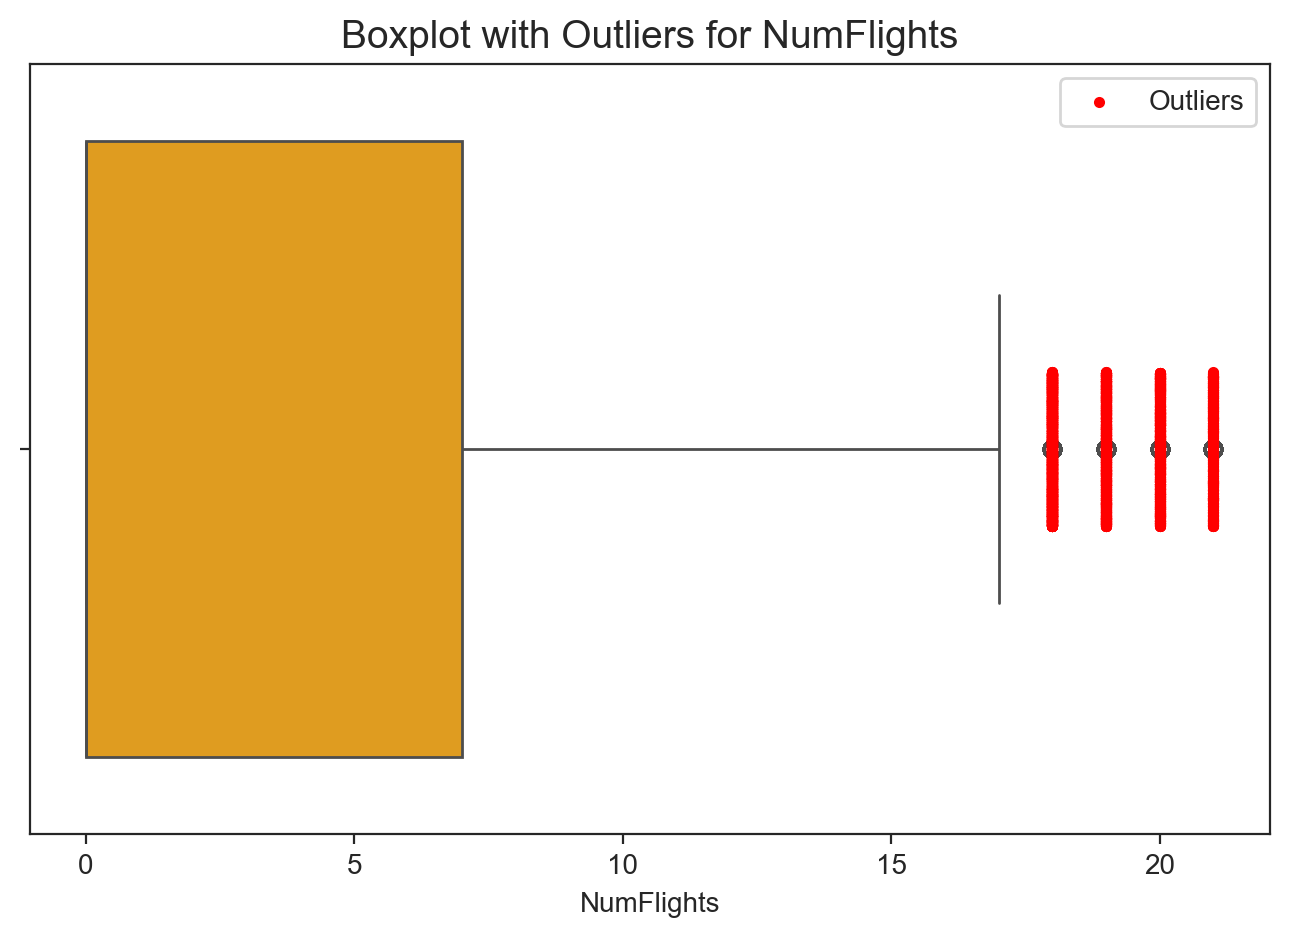

Column: NumFlightsWithCompanions - Number of Outliers: 95880
Column: NumFlightsWithCompanions - % of Outliers: 16.07%



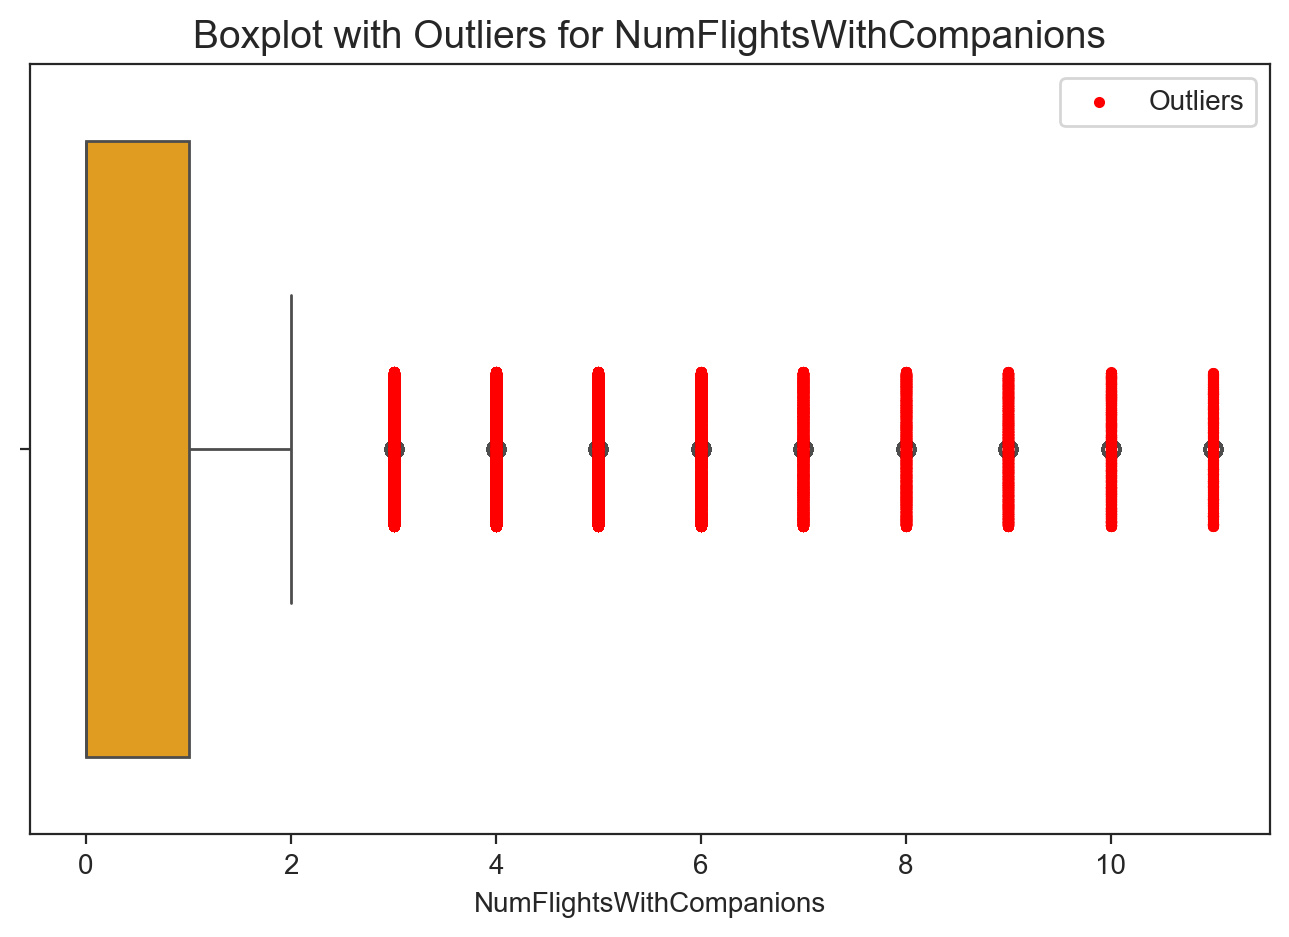

Column: DistanceKM - Number of Outliers: 1828
Column: DistanceKM - % of Outliers: 0.31%



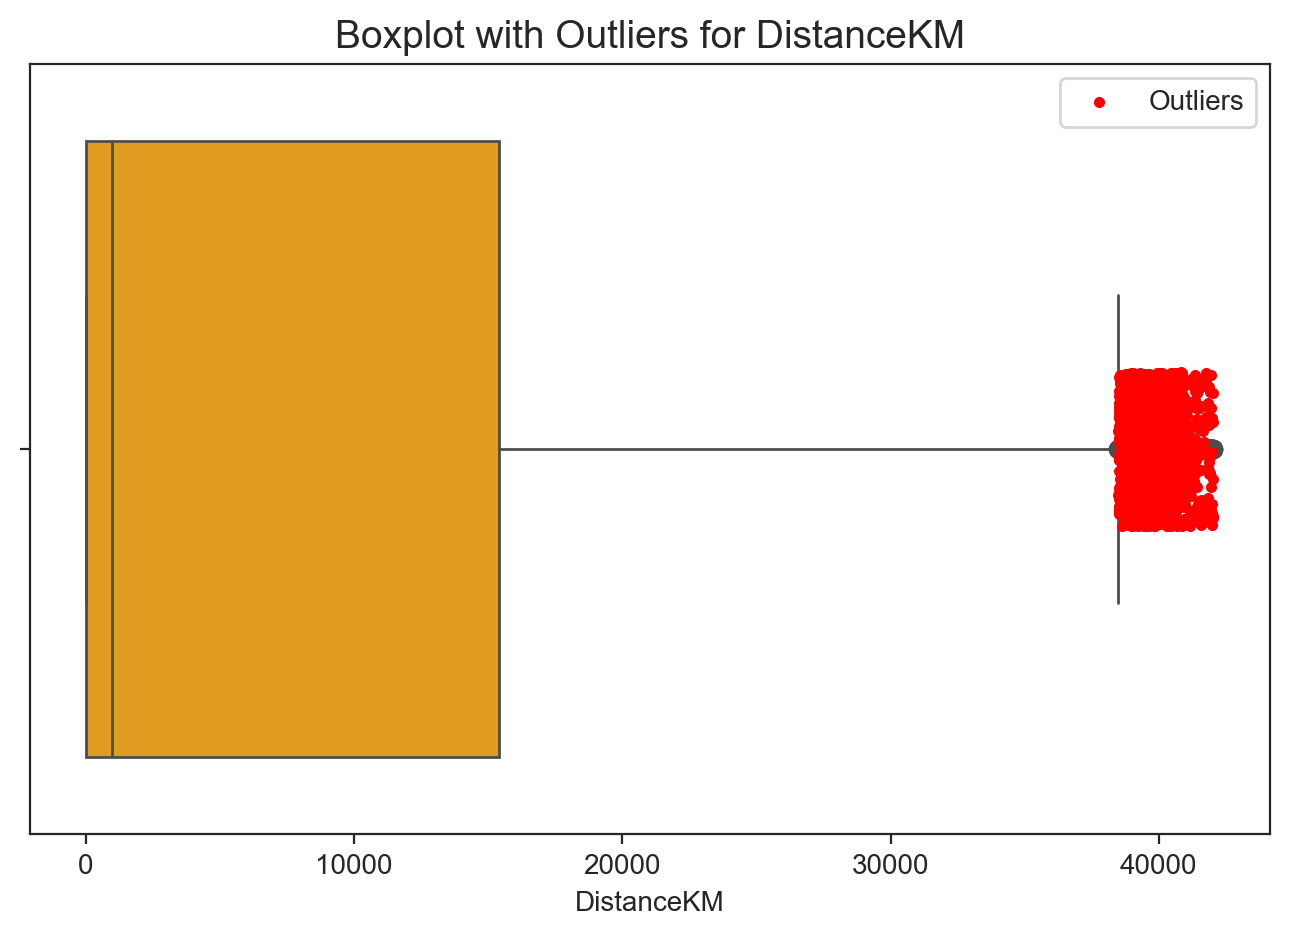

Column: PointsRedeemed - Number of Outliers: 34884
Column: PointsRedeemed - % of Outliers: 5.85%



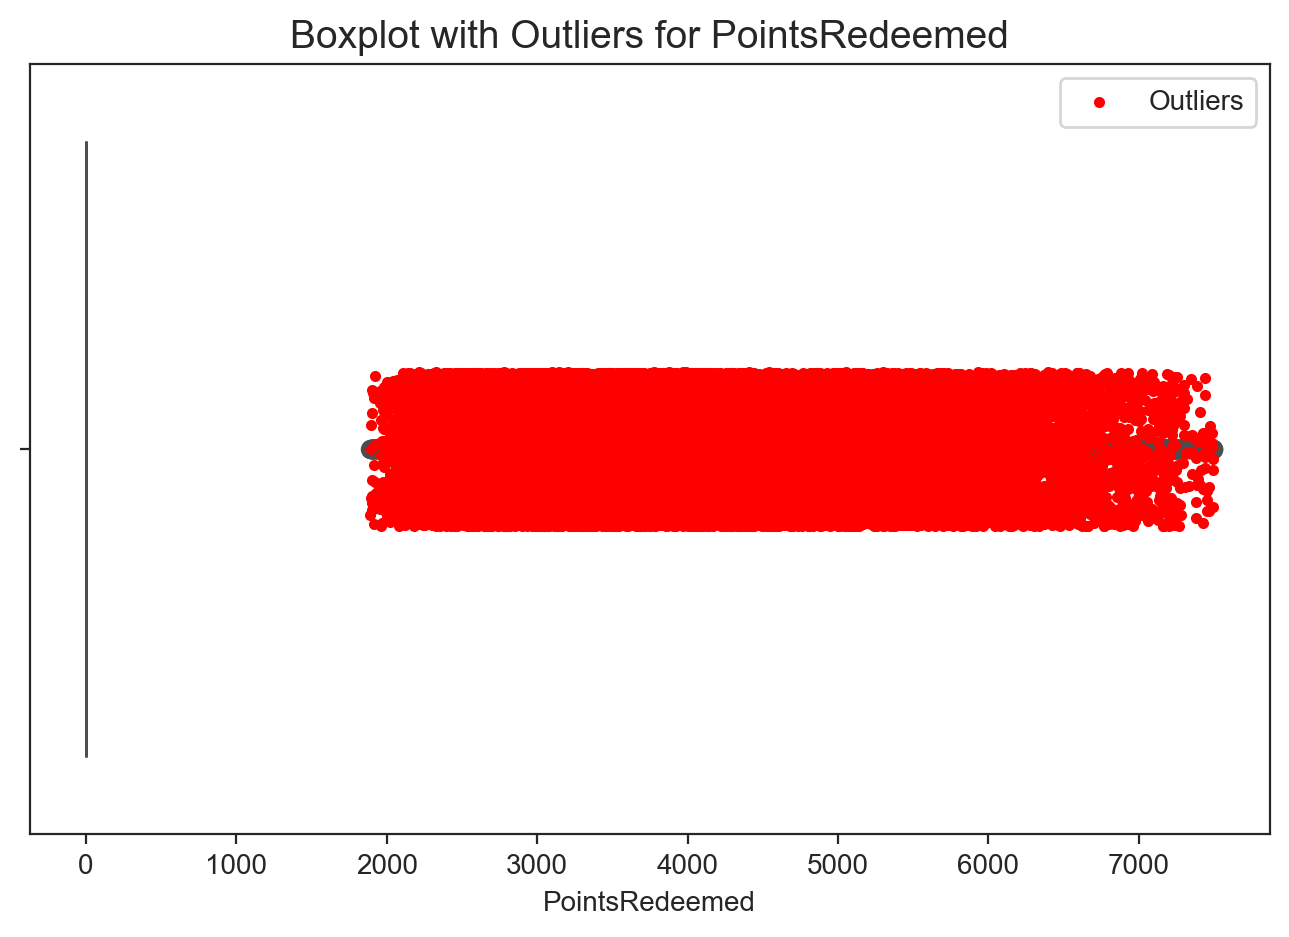

Column: AvgFlightDistance_month - Number of Outliers: 52947
Column: AvgFlightDistance_month - % of Outliers: 8.87%



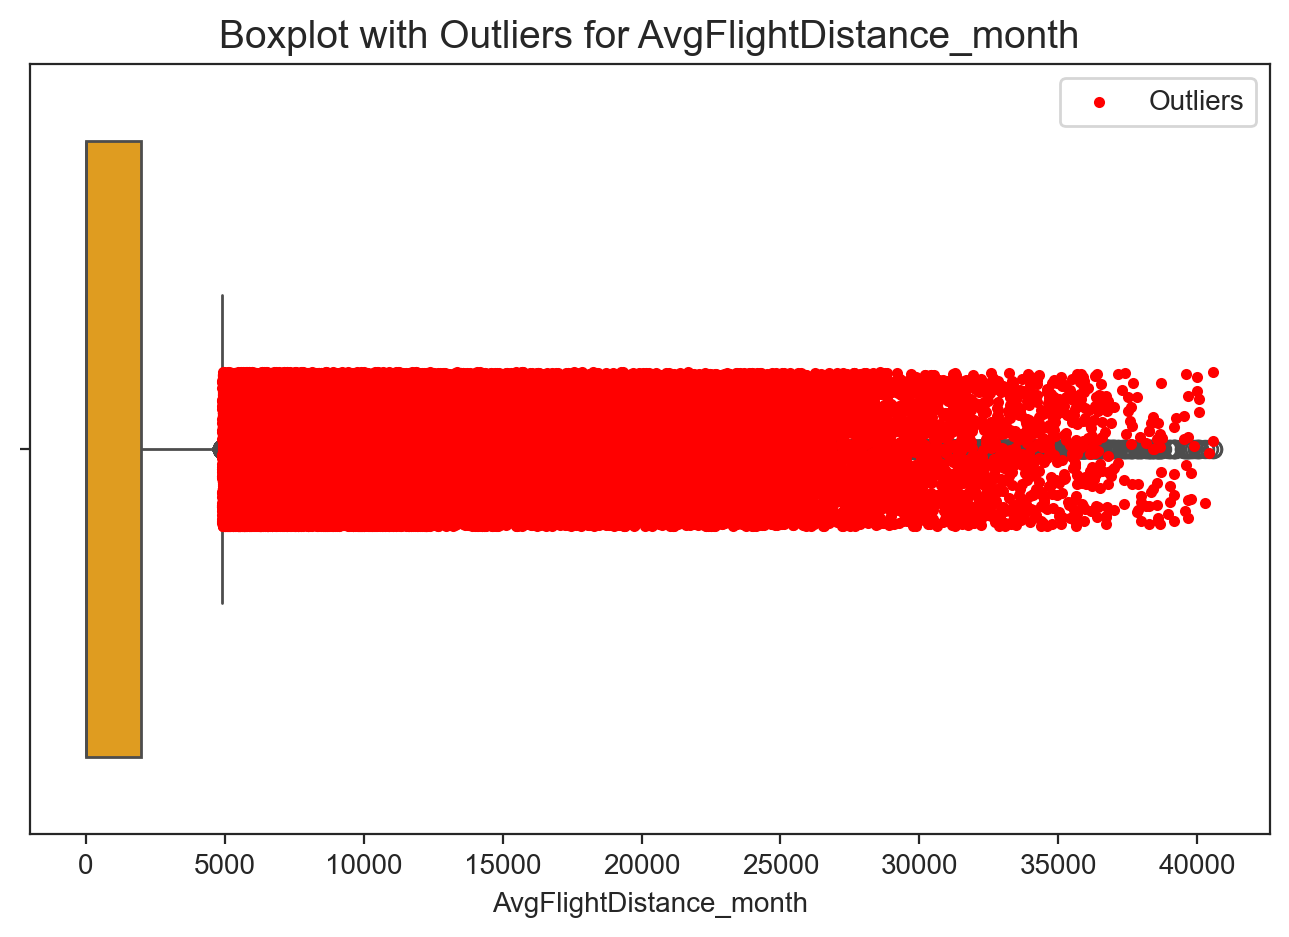

,Column,Num_Outliers,Pct_Outliers
0,NumFlights,6814,1.142016
1,NumFlightsWithCompanions,95880,16.069346
2,DistanceKM,1828,0.306370
3,PointsRedeemed,34884,5.846507
4,AvgFlightDistance_month,52947,8.873839


In [ ]:
detect_outliers_iqr(df_f[df_f_out], 0.001)

<h2>NumFlightsWithCompanions

In [340]:
df_f[df_f['NumFlightsWithCompanions'] == 5].shape

(18343, 11)

In [341]:
df_f[df_f['NumFlightsWithCompanions'] == 10].shape

(1051, 11)

Lower NumFlightsWithCompanions values have more observations, as expected.

<h2>AvgFlightDistance_month

AvgFlightDistance_month measures the average distance traveled per flight by a customer in a single month. The longest flight in 2025 is New York (JFK) – Singapore (SIN) with 15,349 km (9,537 mi) of Flight Distance (https://airinsight.com/top-10-longest-flights-in-2025/). This means that AvgFlightDistance_month values above 15.349 KM are unrealistic and probably an identation error of NumFlights or DistanceKM.

In [342]:
df_f[df_f['AvgFlightDistance_month']>15349].sample(10)

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,AvgFlightDistance_month
517622,663757,2019,7,2019-07-01,2,2,31585.5,3158.55,0.0,0.0,15792.75
509736,245604,2019,7,2019-07-01,2,0,34597.8,3459.78,0.0,0.0,17298.90
314142,409051,2020,11,2020-11-01,1,1,15596.0,1559.00,4531.0,45.0,15596.00
195610,197608,2021,8,2021-08-01,2,2,32653.0,3265.00,0.0,0.0,16326.50
255896,667860,2021,2,2021-02-01,1,1,17942.0,1794.00,0.0,0.0,17942.00
119519,274473,2021,11,2021-11-01,1,0,22951.0,2295.00,0.0,0.0,22951.00
512206,376862,2019,7,2019-07-01,1,1,16408.8,1640.88,5949.0,59.4,16408.80
566773,581260,2019,10,2019-10-01,1,0,23039.1,2303.91,0.0,0.0,23039.10
77902,407340,2020,1,2020-01-01,1,0,20186.0,2018.00,0.0,0.0,20186.00
573607,945765,2019,10,2019-10-01,1,1,25603.2,2560.32,0.0,0.0,25603.20


All of these flights have 1-2 Number of flights in that month (NumFlights) and DistanceKM is in sinc with PointAccumulated. It looks like an identation error from NumFlights variable. Therefore we will set those as missing values to impute them later.

In [343]:
#set NumFlights where AvgFlightDistance_month is >15349 to NaN
df_f.loc[df_f['AvgFlightDistance_month']>15349, 'NumFlights'] = np.nan

In [344]:
df_f.isna().sum()

Loyalty#                       0
Year                           0
Month                          0
YearMonthDate                  0
NumFlights                  9955
NumFlightsWithCompanions       0
DistanceKM                     0
PointsAccumulated              0
PointsRedeemed                 0
DollarCostPointsRedeemed       0
AvgFlightDistance_month        0
dtype: int64

### Flights dataset aggregated by customer

In [345]:
# Aggregate by client - Loyalty 
df_f_agg = (df_f.groupby("Loyalty#").agg(
    {"Year": ["nunique"],                     
    "Month": ["nunique"],                    
    "NumFlights": ["sum", "mean", "max"],    
    "NumFlightsWithCompanions": ["sum", "mean"],  
    "DistanceKM": ["sum", "mean", "max"],    
    "PointsAccumulated": ["sum", "mean"],    
    "PointsRedeemed": ["sum", "mean"],       
    "DollarCostPointsRedeemed": ["sum", "mean"]}).reset_index())

# I know there are a lot of variables, but u never know if we will use them. In the end, they can be removed
df_f_agg.columns = ["Loyalty#", "Years_Active", "Months_Active", "Flights_Sum", "Flights_Mean", "Flights_Max",
                          "FlightsComp_Sum", "FlightsComp_Mean", "DistKM_Sum", "DistKM_Mean", "DistKM_Max", "PtsAcc_Sum", "PtsAcc_Mean",
                          "PtsRed_Sum", "PtsRed_Mean", "CostPts_Sum", "CostPts_Mean"]

# Feature Engineering (some variables created that could be important)
# Ratio between Points Redeemed and Points Accumulated over the time
df_f_agg["PointsEfficiency"] = (
    df_f_agg["PtsRed_Sum"] / df_f_agg["PtsAcc_Sum"]
).replace([np.inf, np.nan], 0)

# Distance
df_f_agg["DistPerFlight"] = (
    df_f_agg["DistKM_Sum"] / df_f_agg["Flights_Sum"]
).replace([np.inf, np.nan], 0)


## Merge both datasets

In [346]:
df_merged = df_f.merge(df_c, on='Loyalty#', how='left')
df_merged.shape

(596664, 29)

In [347]:
df_agg_merged = pd.merge(df_c, df_f_agg, on="Loyalty#", how="left")
print("Final dimensions:", df_agg_merged.shape)

Final dimensions: (16594, 37)


In [361]:
df_agg_merged.columns

Index(['Loyalty#', 'First Name', 'Last Name', 'Customer Name', 'Country',
       'Province or State', 'City', 'Latitude', 'Longitude', 'Postal code',
       'Gender', 'Education', 'Location Code', 'Income', 'Marital Status',
       'LoyaltyStatus', 'Customer Lifetime Value', 'EnrollmentType',
       'Days_sub', 'Years_Active', 'Months_Active', 'Flights_Sum',
       'Flights_Mean', 'Flights_Max', 'FlightsComp_Sum', 'FlightsComp_Mean',
       'DistKM_Sum', 'DistKM_Mean', 'DistKM_Max', 'PtsAcc_Sum', 'PtsAcc_Mean',
       'PtsRed_Sum', 'PtsRed_Mean', 'CostPts_Sum', 'CostPts_Mean',
       'PointsEfficiency', 'DistPerFlight'],
      dtype='object')

In [362]:
df_agg_merged_out = ['Income', 'Customer Lifetime Value',
       'Days_sub', 'Flights_Sum',
       'Flights_Mean', 'Flights_Max', 'FlightsComp_Sum', 'FlightsComp_Mean',
       'DistKM_Sum', 'DistKM_Mean', 'DistKM_Max', 'PtsAcc_Sum', 'PtsAcc_Mean',
       'PtsRed_Sum', 'PtsRed_Mean', 'CostPts_Sum', 'CostPts_Mean',
       'PointsEfficiency', 'DistPerFlight']

Column: Income - Number of Outliers: 0
Column: Income - % of Outliers: 0.00%



/var/folders/vb/yhn0331x30n4j9b7wy_v2chm0000gn/T/ipykernel_10405/2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


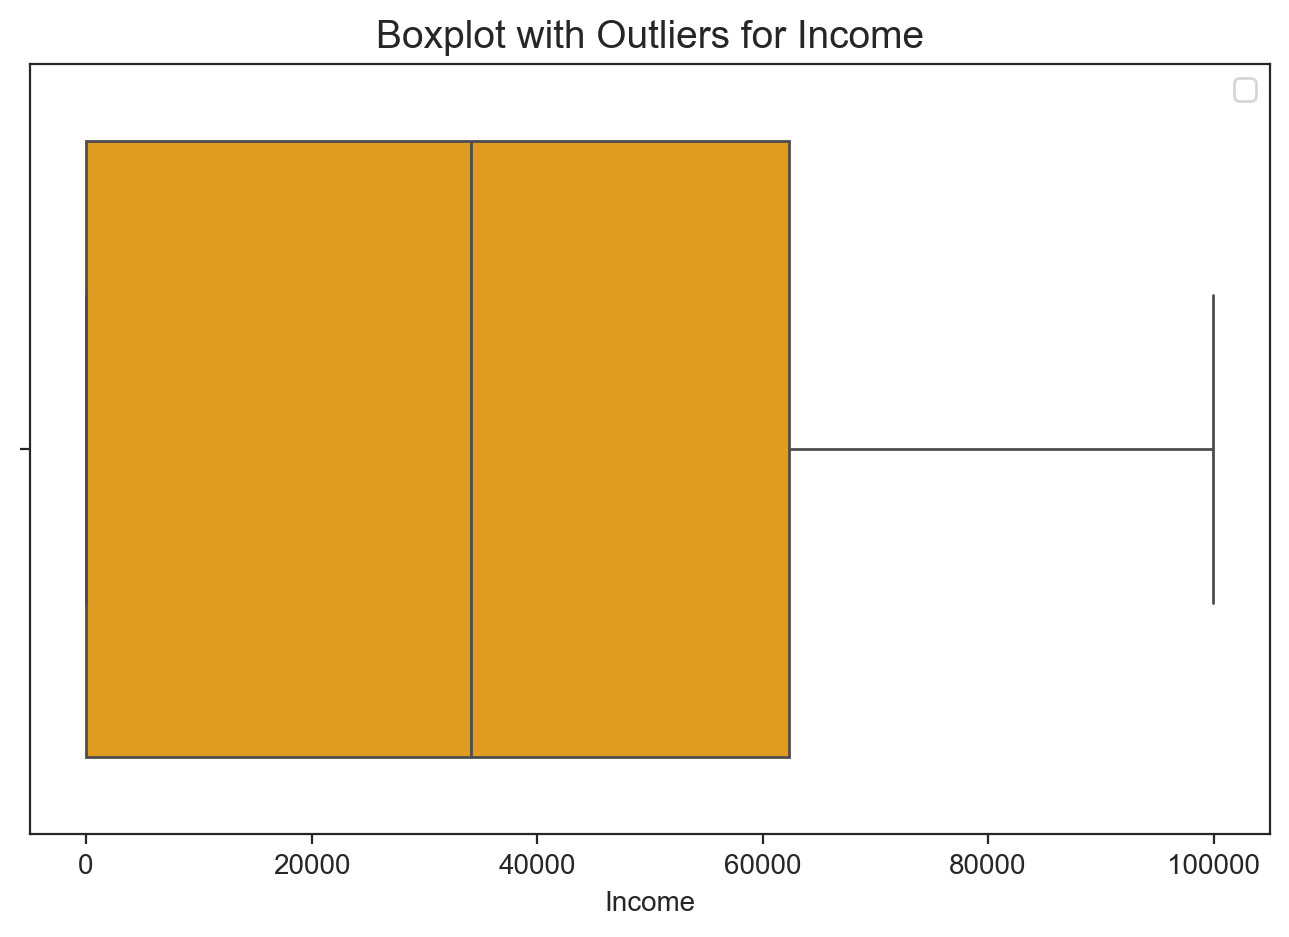

Column: Customer Lifetime Value - Number of Outliers: 1460
Column: Customer Lifetime Value - % of Outliers: 8.80%



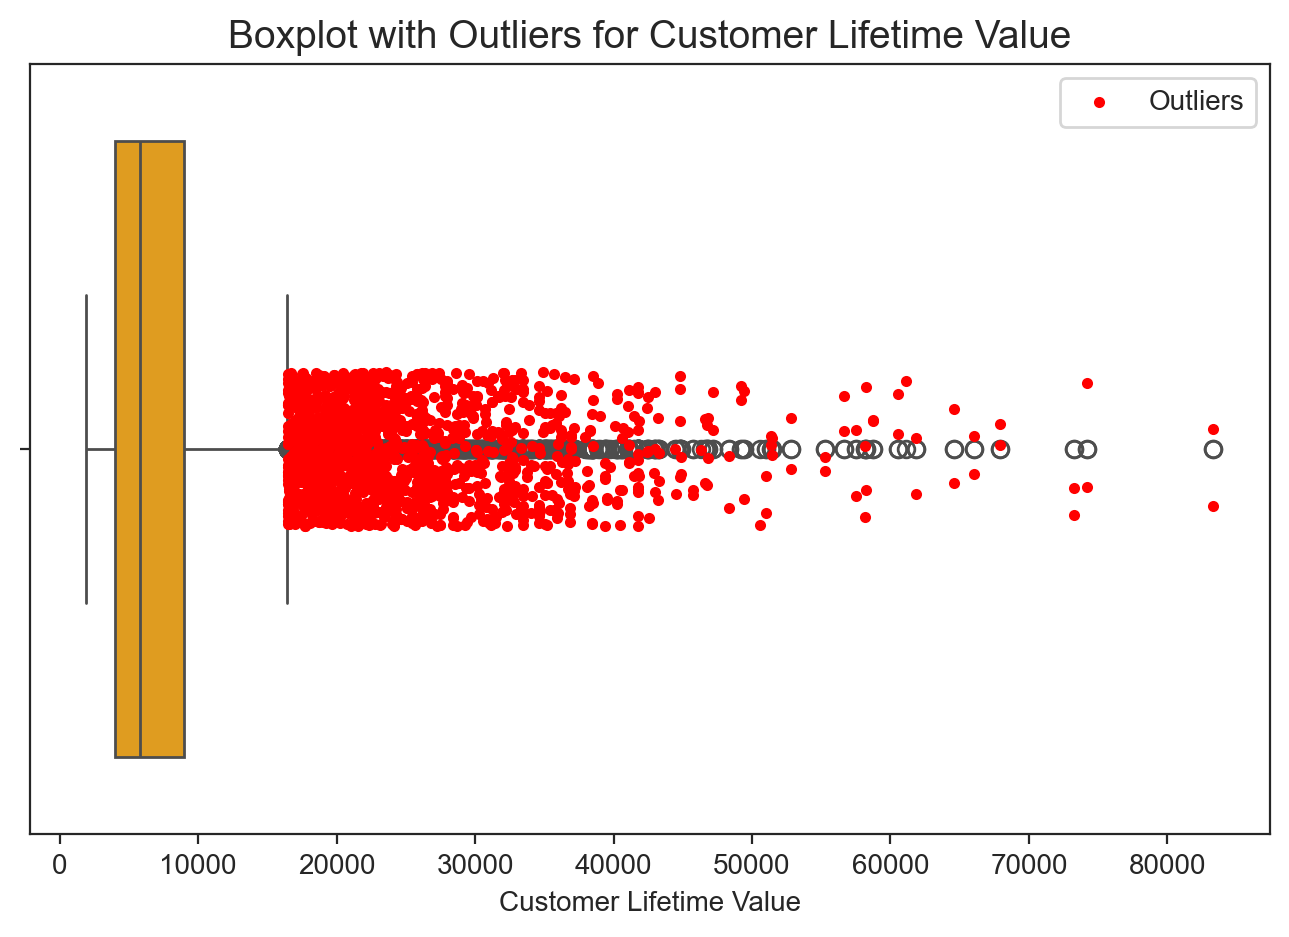

Column: Days_sub - Number of Outliers: 0
Column: Days_sub - % of Outliers: 0.00%



/var/folders/vb/yhn0331x30n4j9b7wy_v2chm0000gn/T/ipykernel_10405/2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


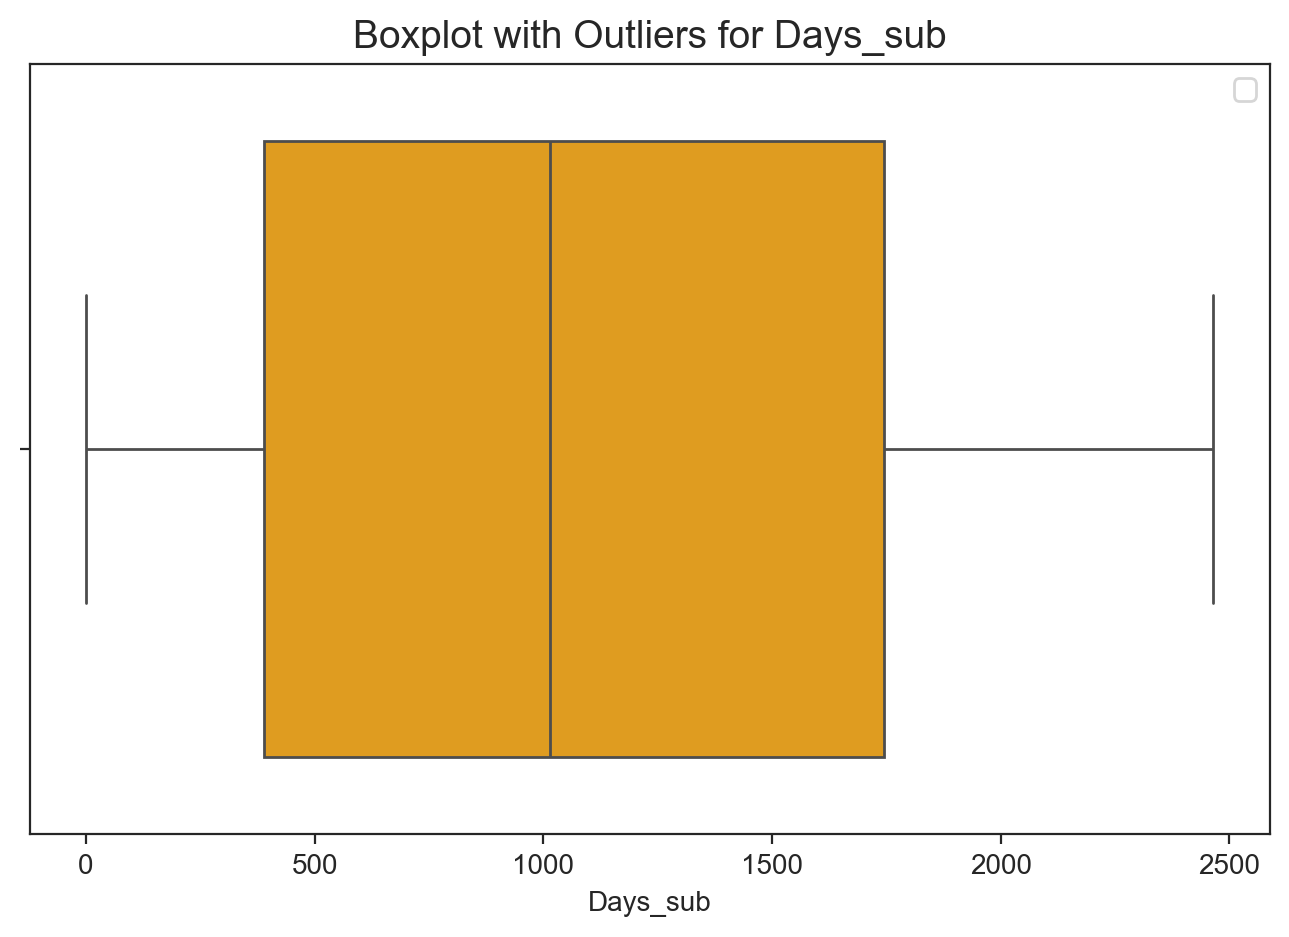

/var/folders/vb/yhn0331x30n4j9b7wy_v2chm0000gn/T/ipykernel_10405/2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Column: Flights_Sum - Number of Outliers: 0
Column: Flights_Sum - % of Outliers: 0.00%



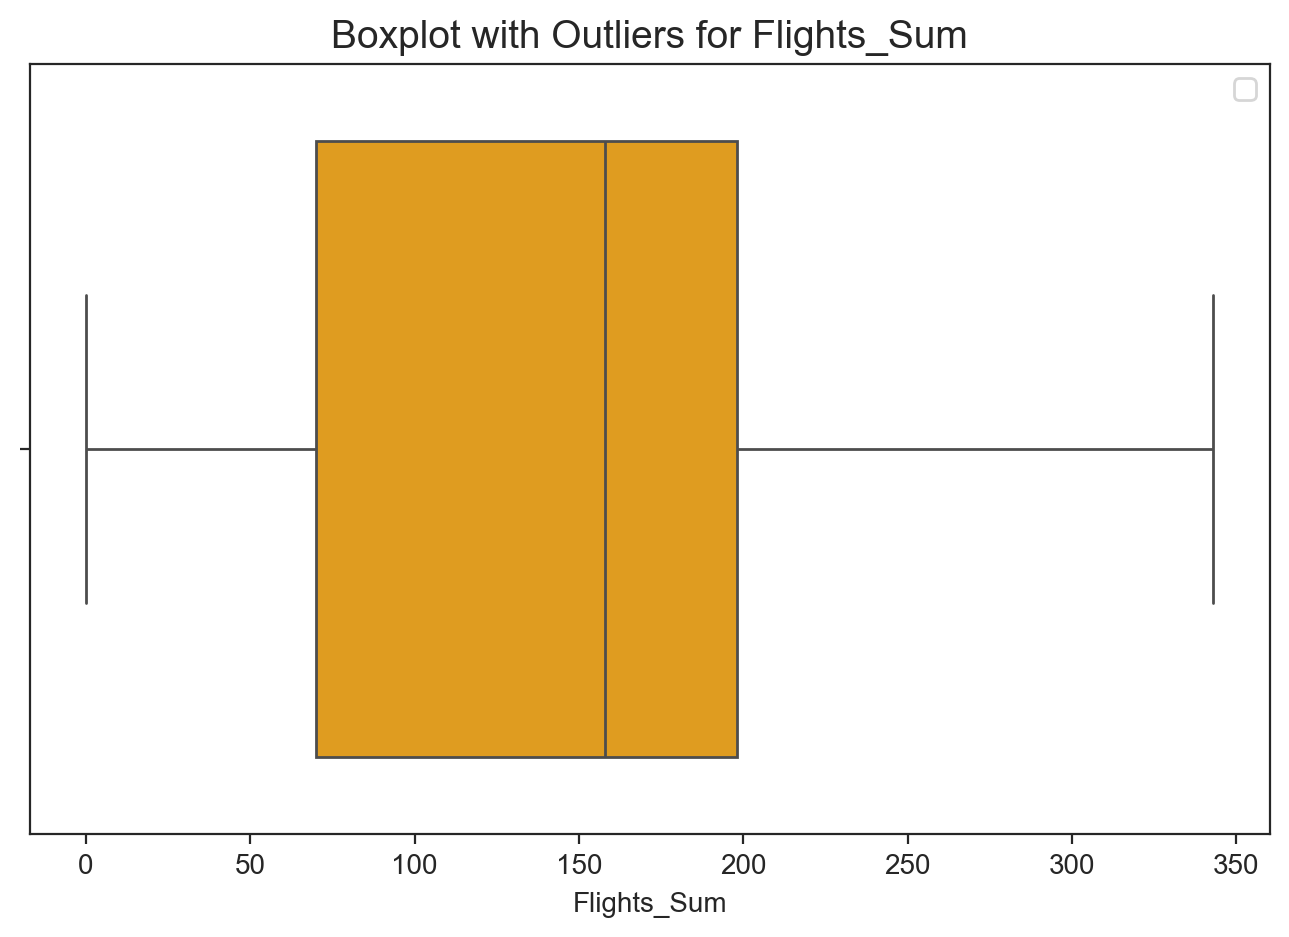

Column: Flights_Mean - Number of Outliers: 0
Column: Flights_Mean - % of Outliers: 0.00%



/var/folders/vb/yhn0331x30n4j9b7wy_v2chm0000gn/T/ipykernel_10405/2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


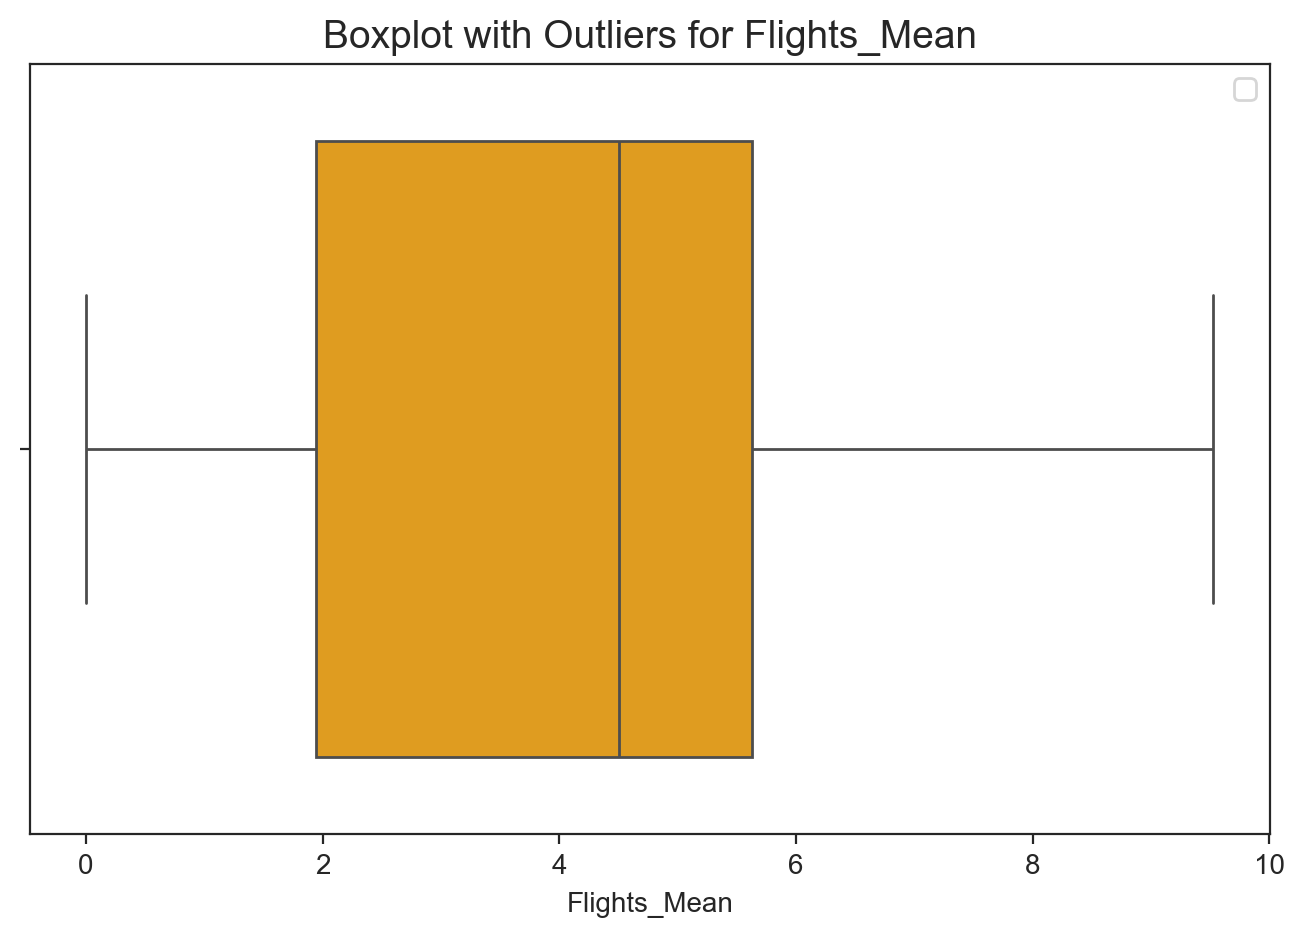

Column: Flights_Max - Number of Outliers: 1669
Column: Flights_Max - % of Outliers: 10.06%



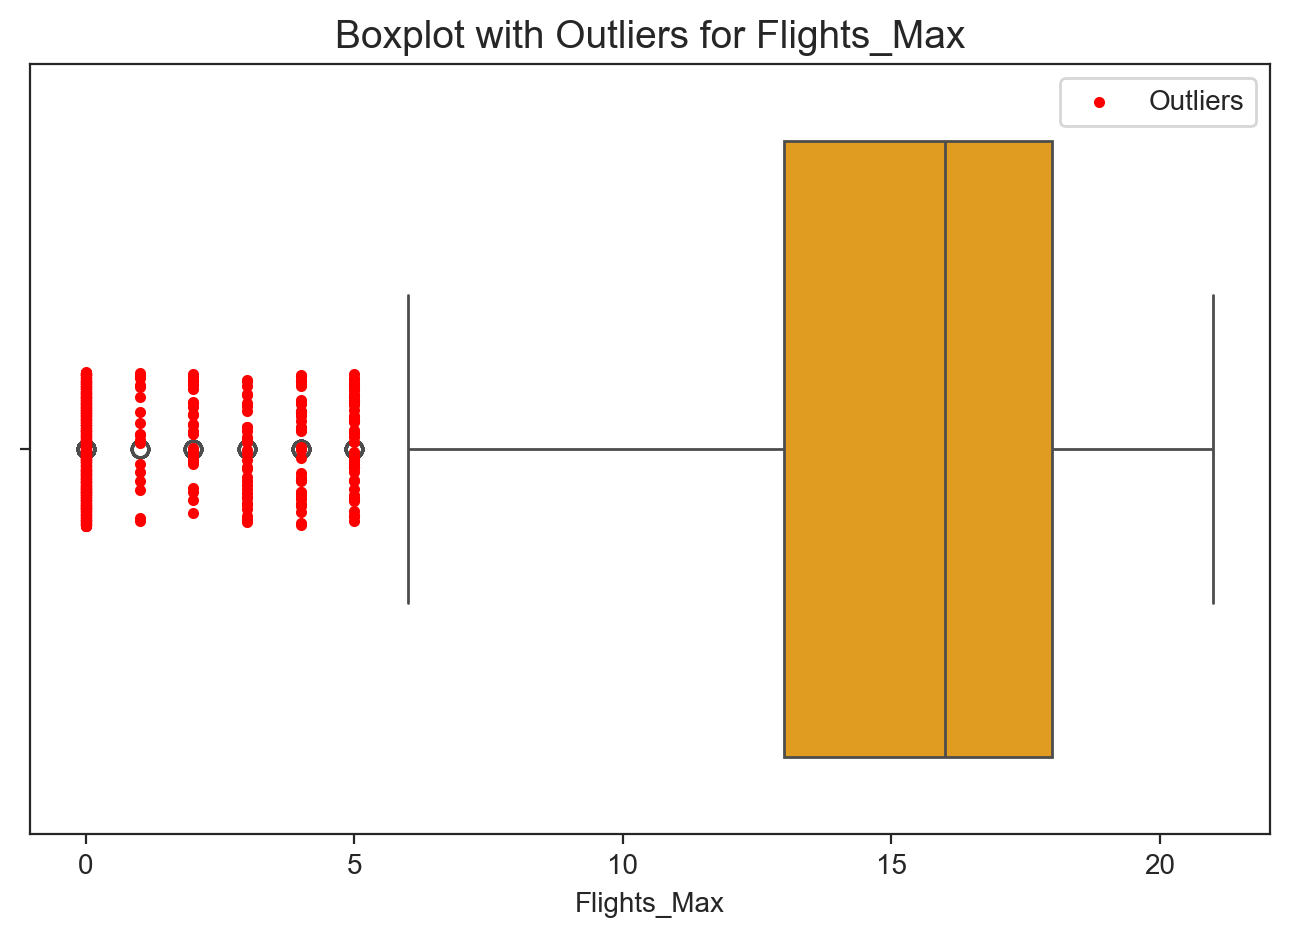

Column: FlightsComp_Sum - Number of Outliers: 18
Column: FlightsComp_Sum - % of Outliers: 0.11%



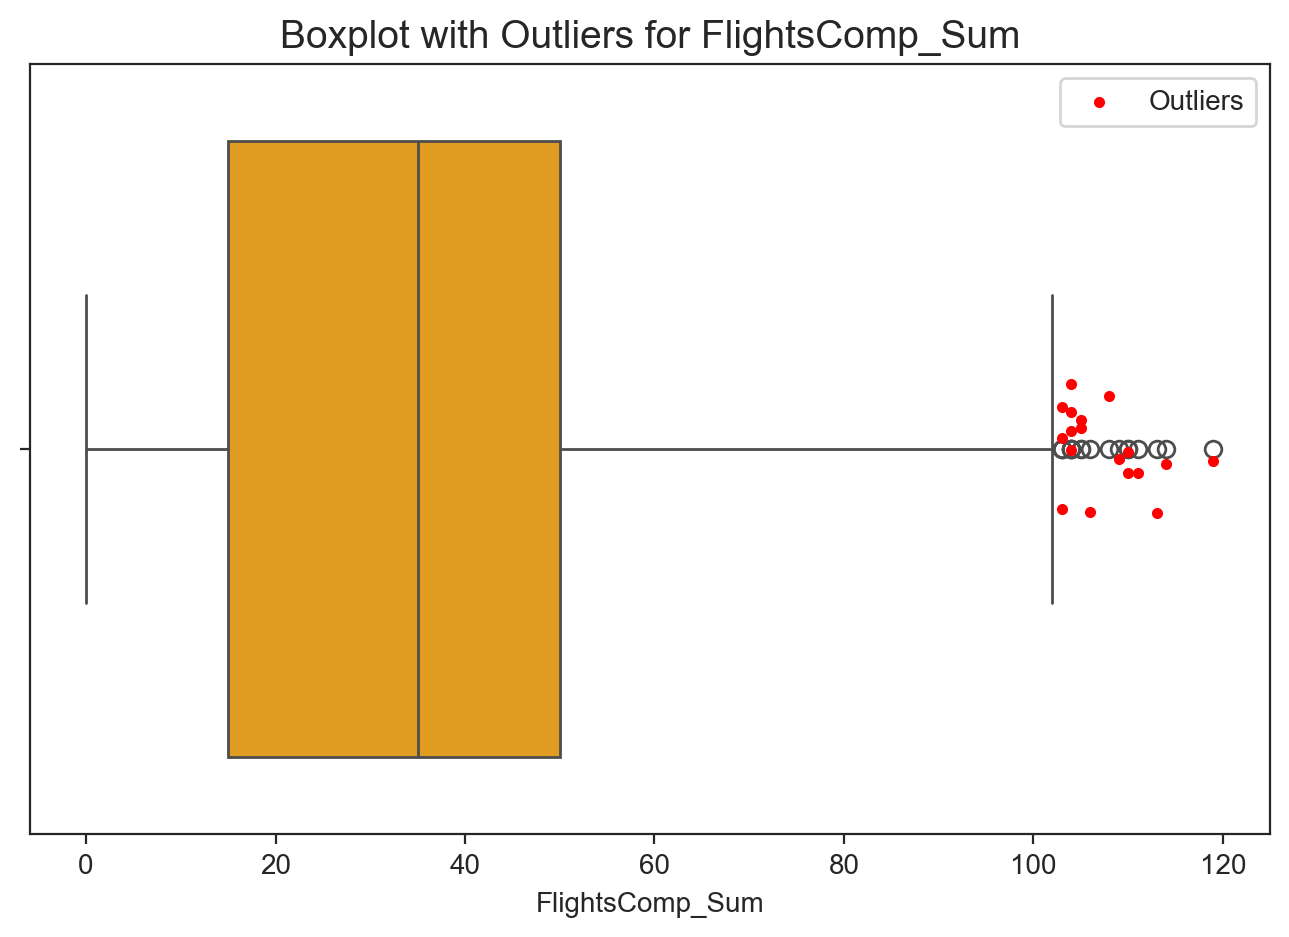

Column: FlightsComp_Mean - Number of Outliers: 18
Column: FlightsComp_Mean - % of Outliers: 0.11%



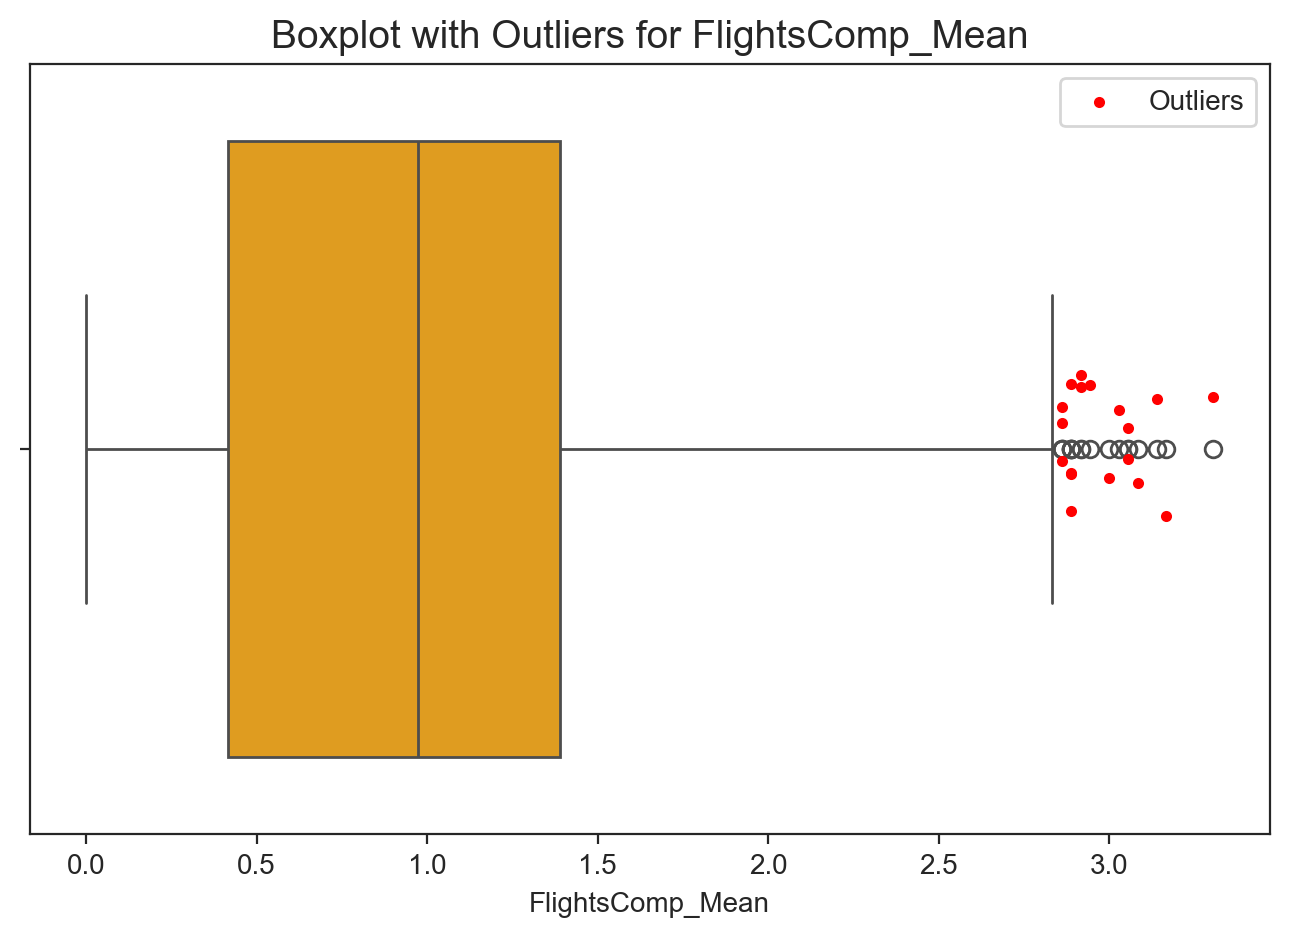

Column: DistKM_Sum - Number of Outliers: 0
Column: DistKM_Sum - % of Outliers: 0.00%



/var/folders/vb/yhn0331x30n4j9b7wy_v2chm0000gn/T/ipykernel_10405/2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


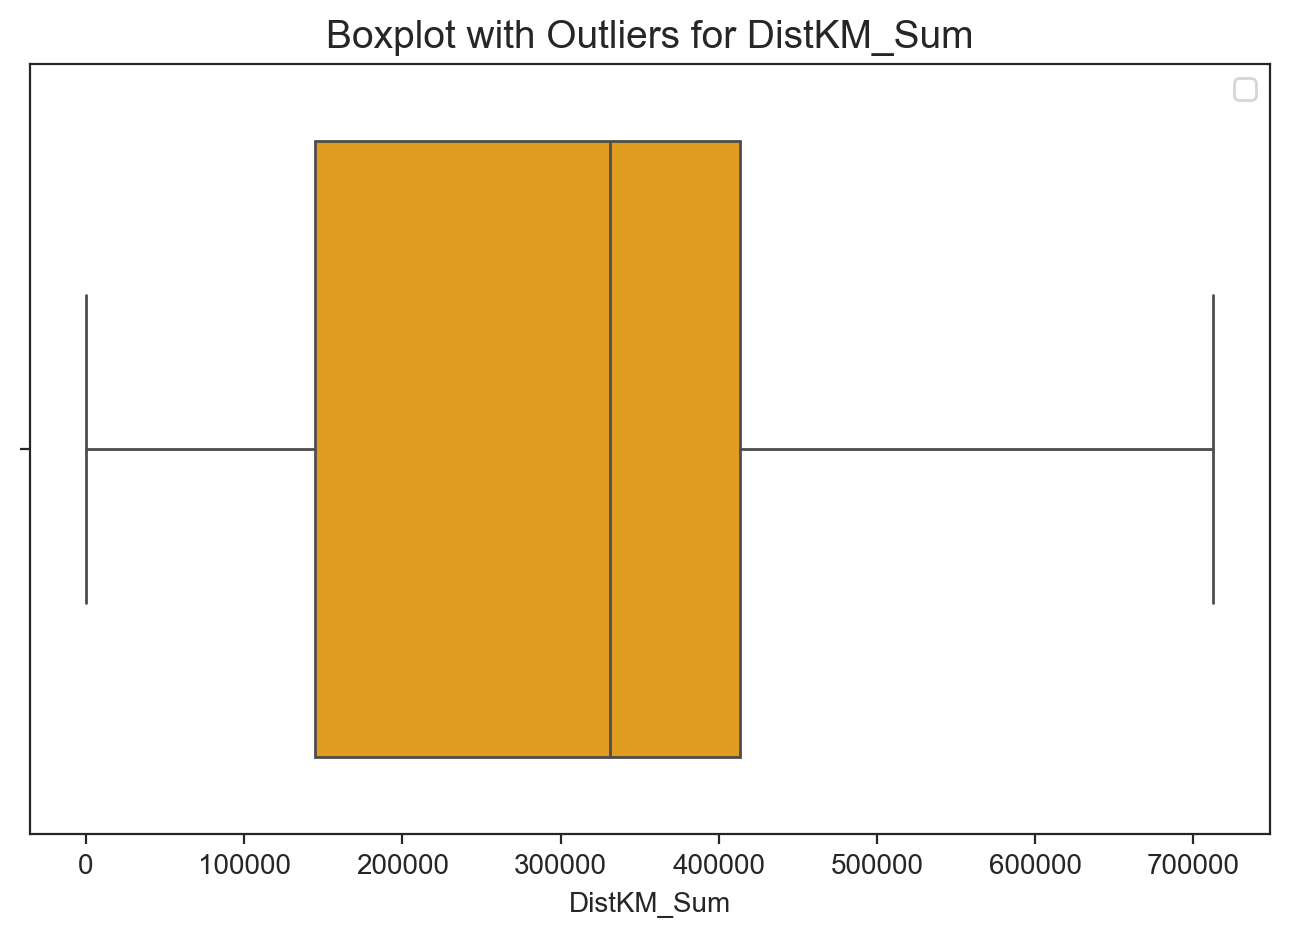

Column: DistKM_Mean - Number of Outliers: 0
Column: DistKM_Mean - % of Outliers: 0.00%



/var/folders/vb/yhn0331x30n4j9b7wy_v2chm0000gn/T/ipykernel_10405/2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


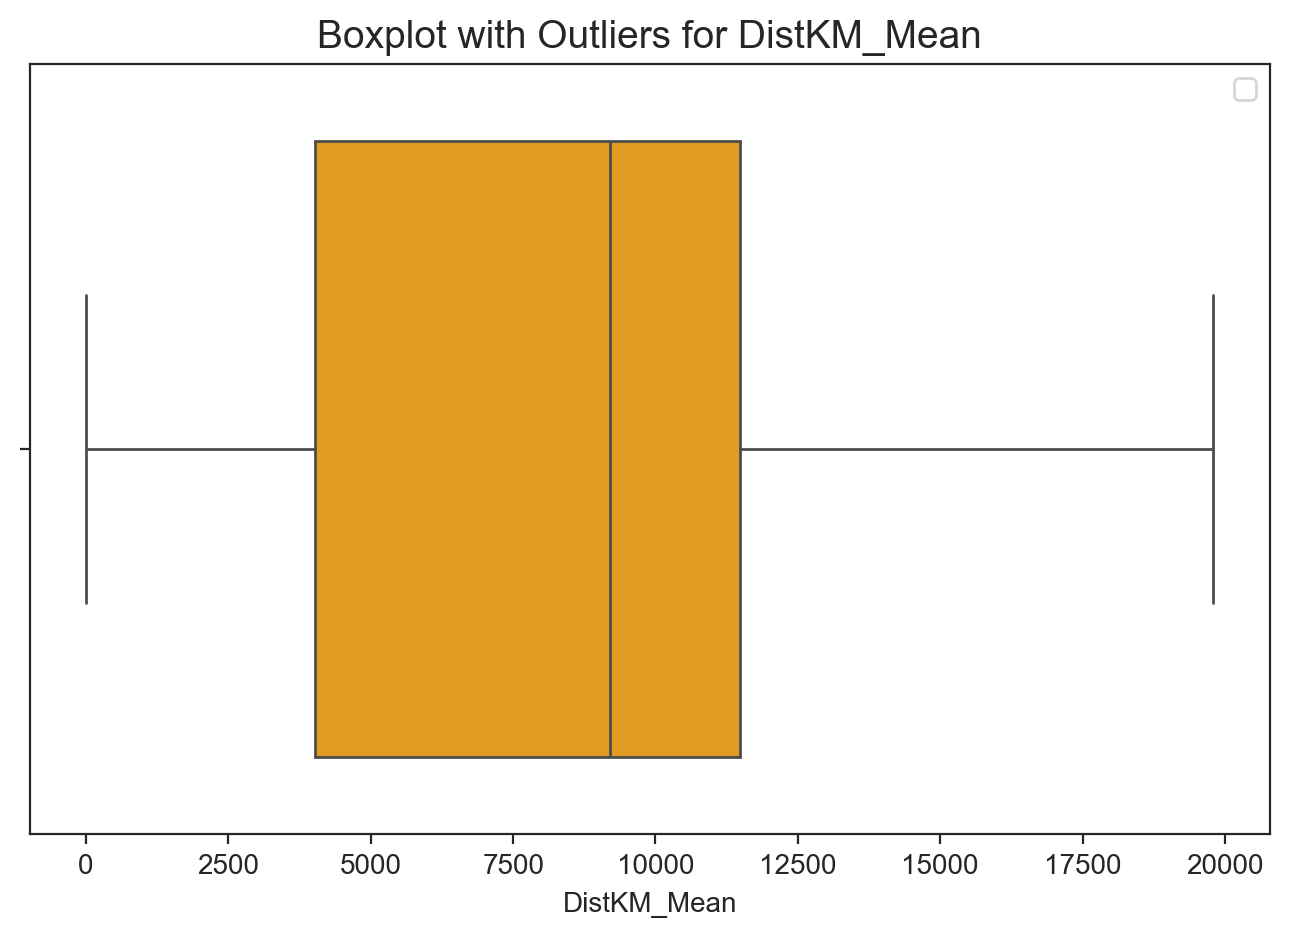

Column: DistKM_Max - Number of Outliers: 1808
Column: DistKM_Max - % of Outliers: 10.90%



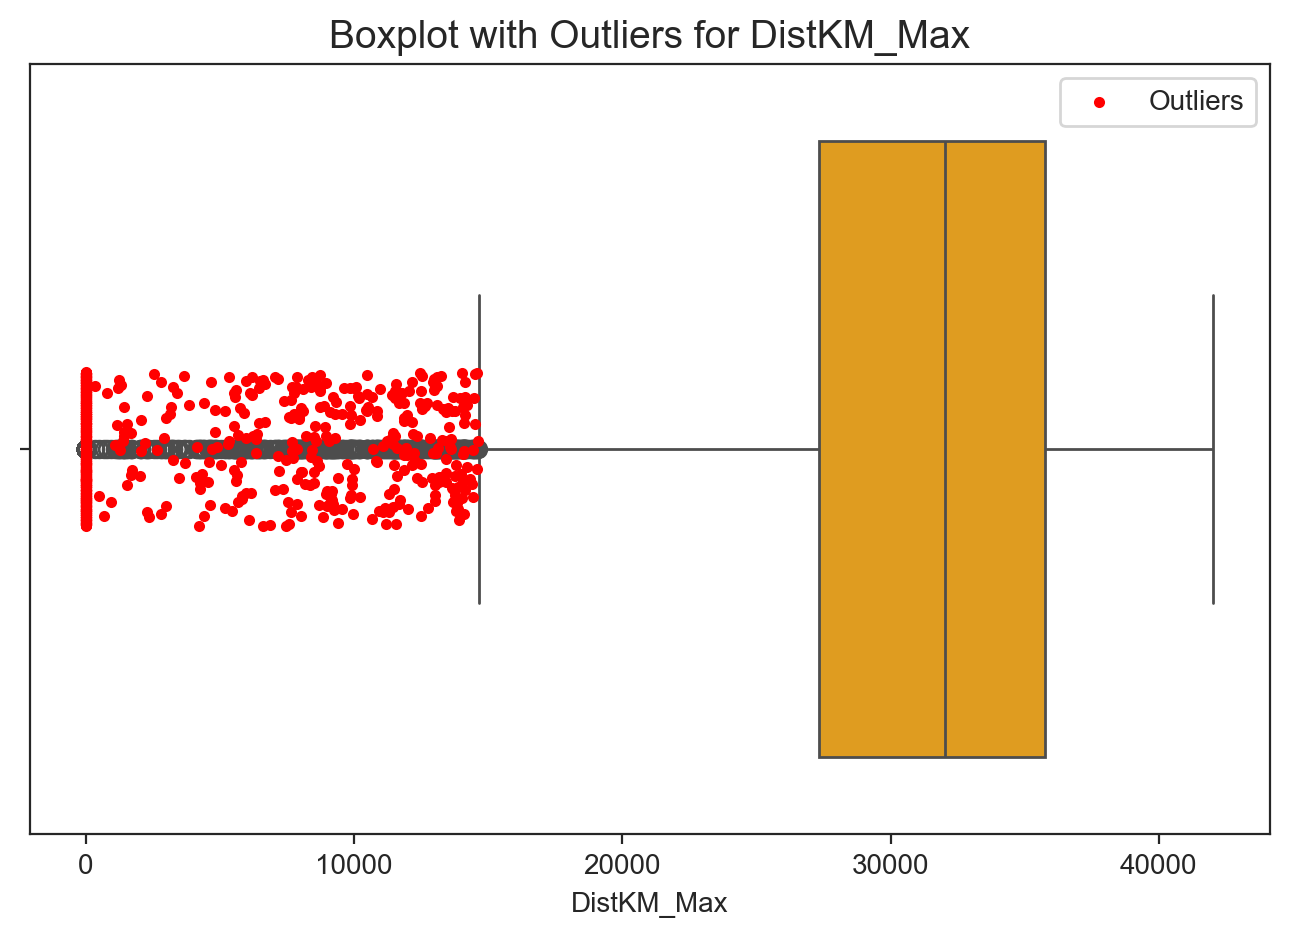

Column: PtsAcc_Sum - Number of Outliers: 0
Column: PtsAcc_Sum - % of Outliers: 0.00%



/var/folders/vb/yhn0331x30n4j9b7wy_v2chm0000gn/T/ipykernel_10405/2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


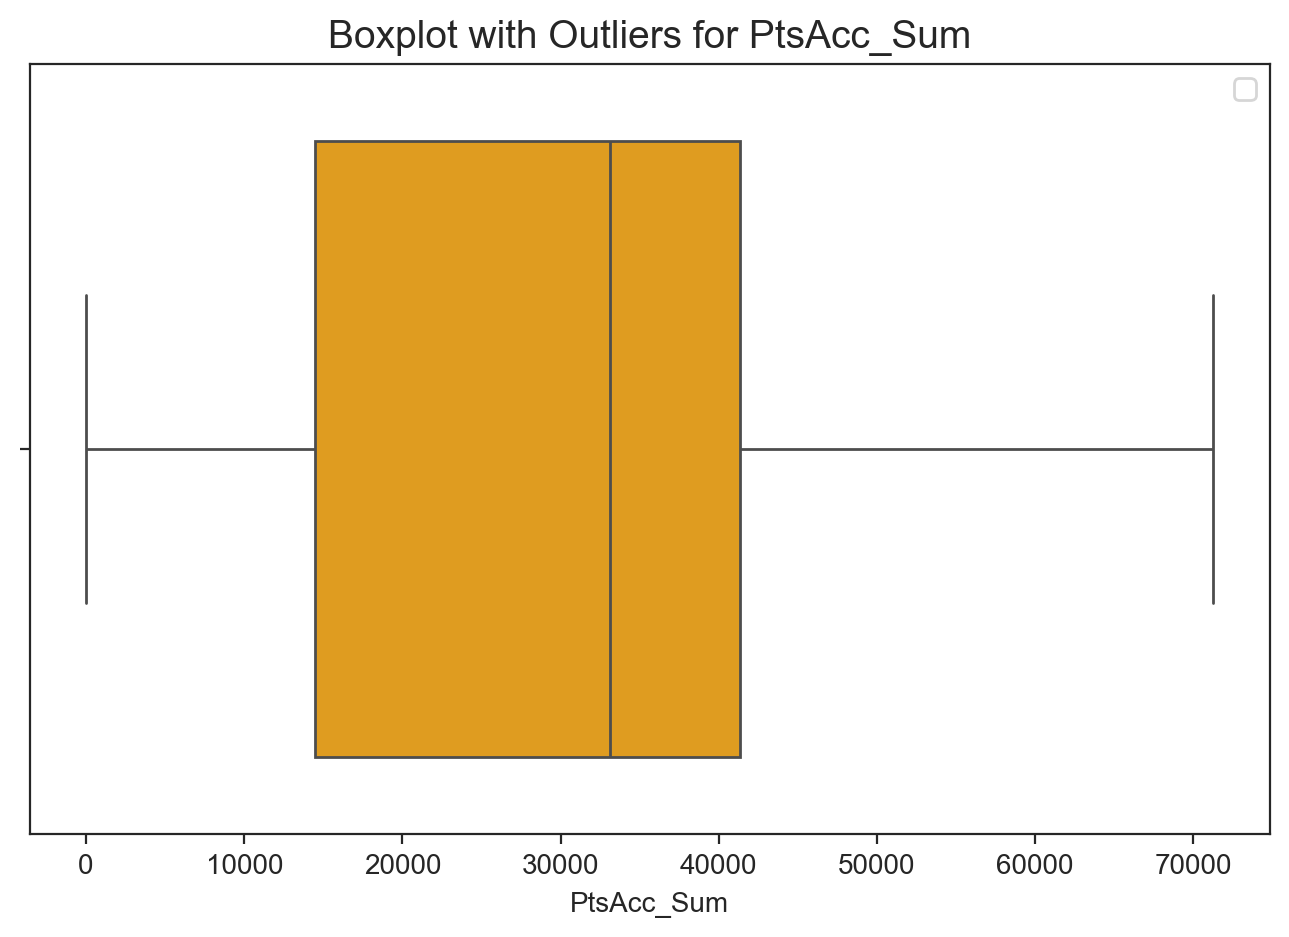

Column: PtsAcc_Mean - Number of Outliers: 0
Column: PtsAcc_Mean - % of Outliers: 0.00%



/var/folders/vb/yhn0331x30n4j9b7wy_v2chm0000gn/T/ipykernel_10405/2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


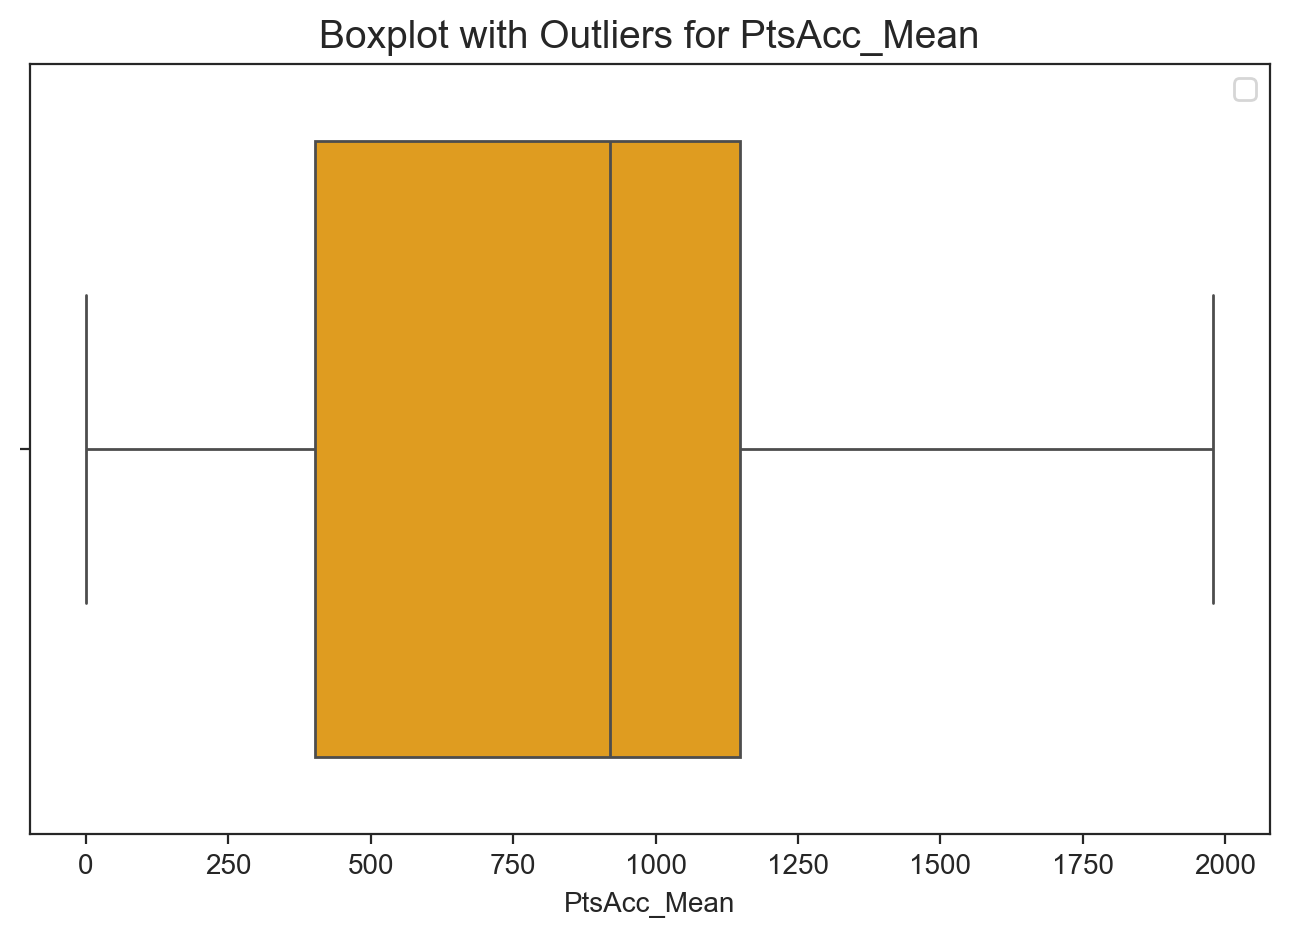

Column: PtsRed_Sum - Number of Outliers: 190
Column: PtsRed_Sum - % of Outliers: 1.14%



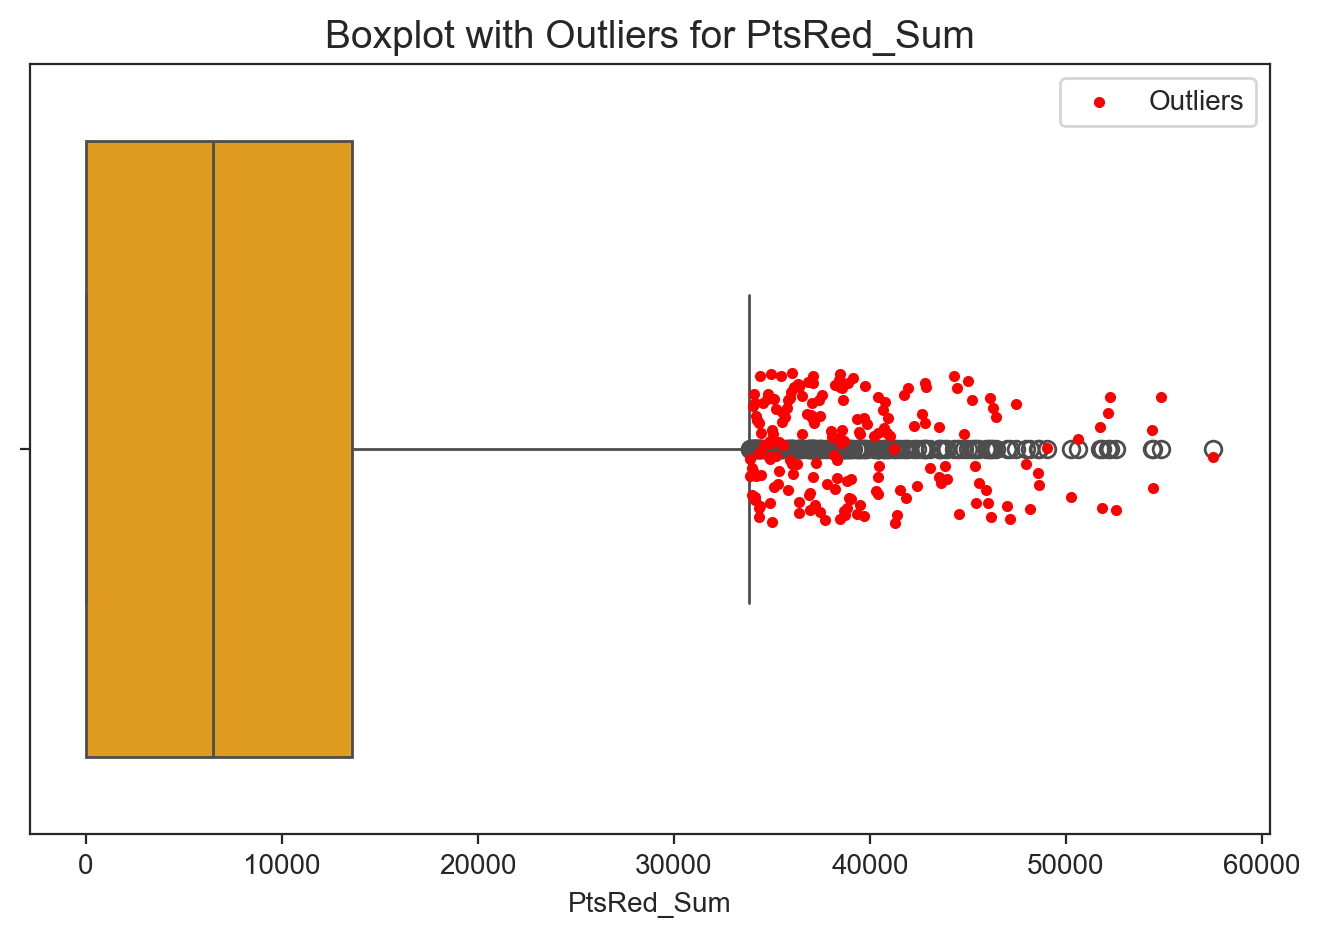

Column: PtsRed_Mean - Number of Outliers: 190
Column: PtsRed_Mean - % of Outliers: 1.14%



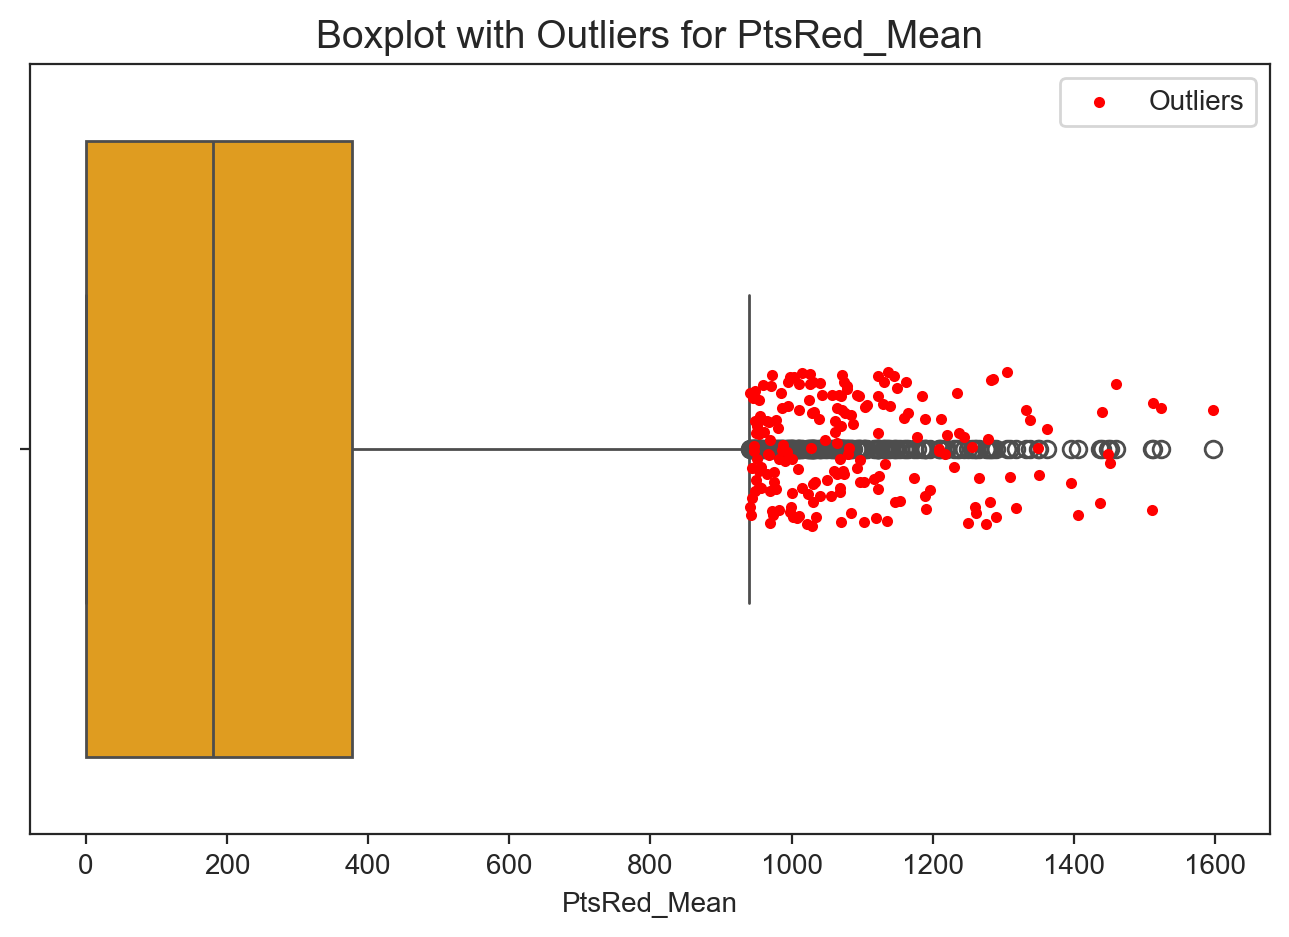

Column: CostPts_Sum - Number of Outliers: 187
Column: CostPts_Sum - % of Outliers: 1.13%



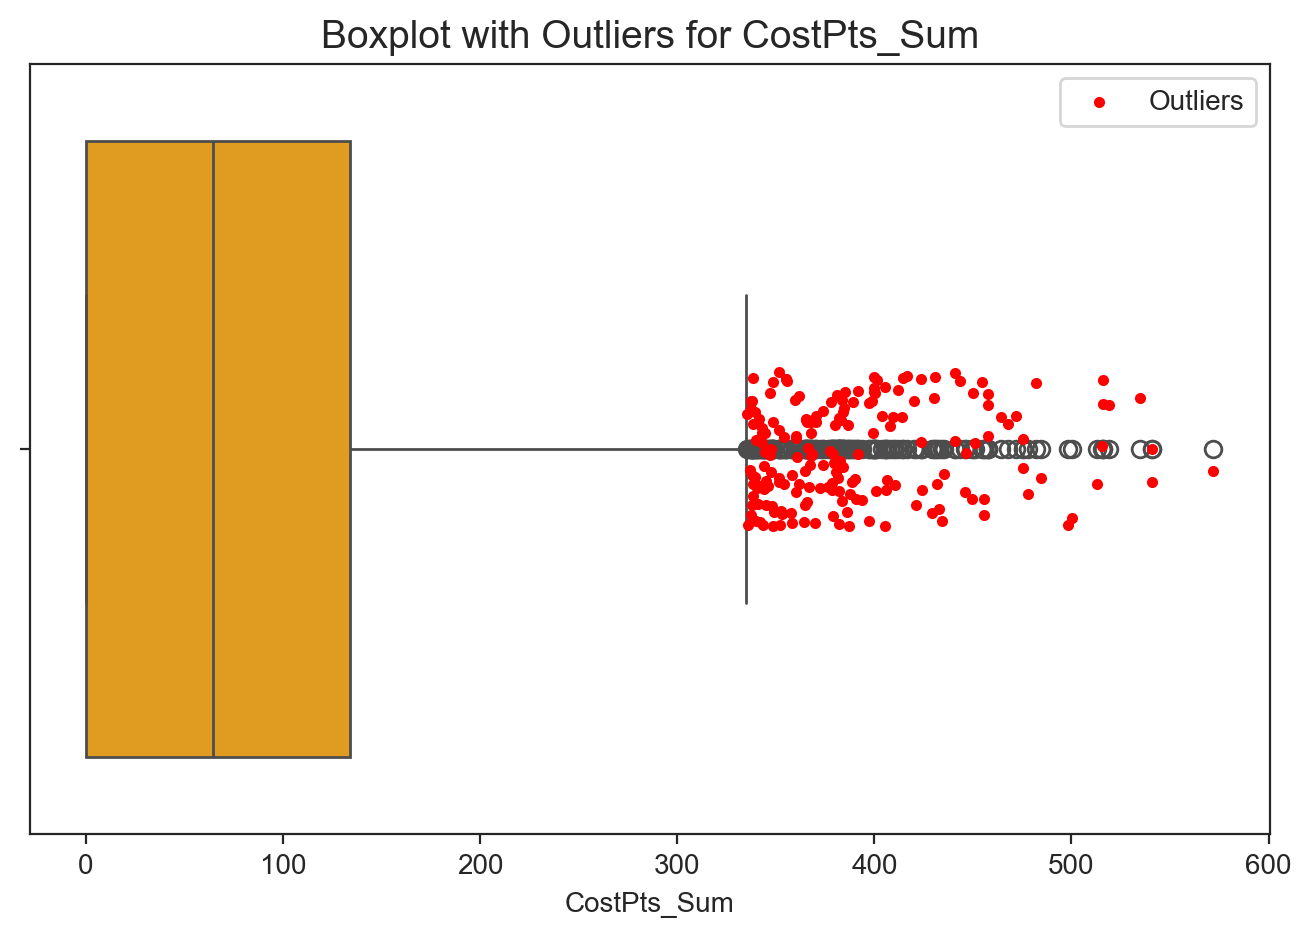

Column: CostPts_Mean - Number of Outliers: 187
Column: CostPts_Mean - % of Outliers: 1.13%



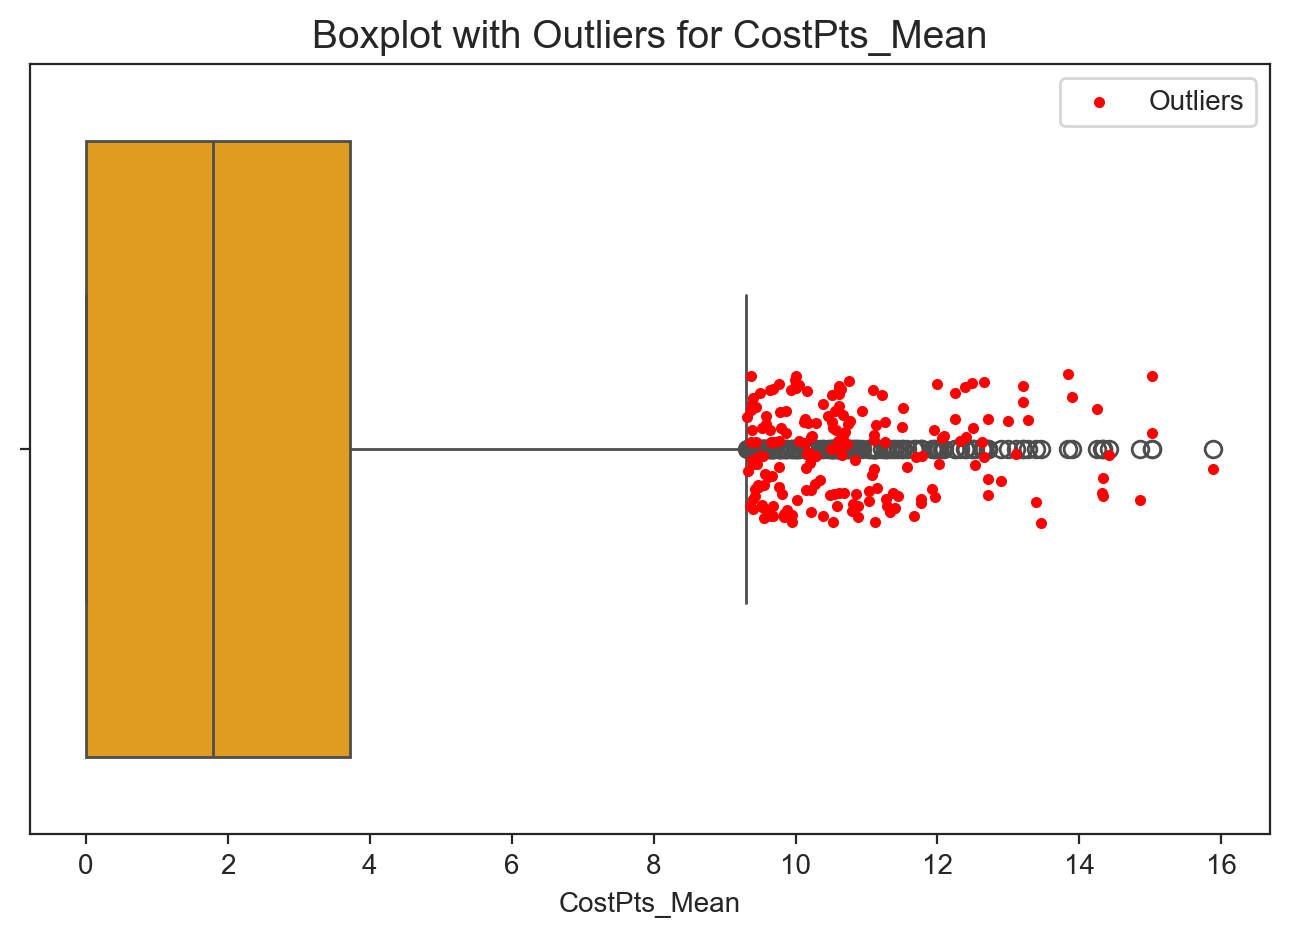

Column: PointsEfficiency - Number of Outliers: 408
Column: PointsEfficiency - % of Outliers: 2.46%



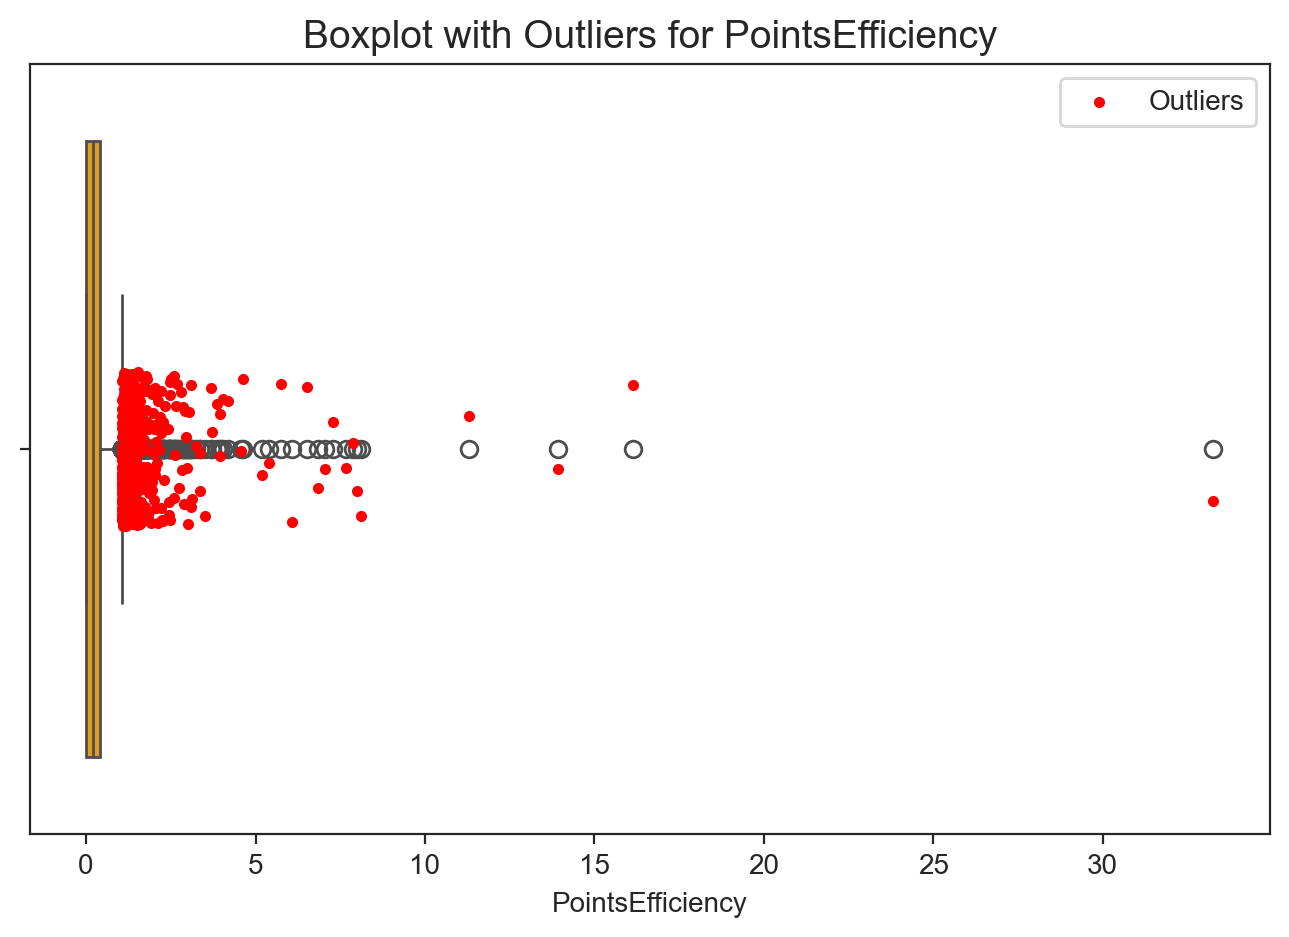

Column: DistPerFlight - Number of Outliers: 2052
Column: DistPerFlight - % of Outliers: 12.37%



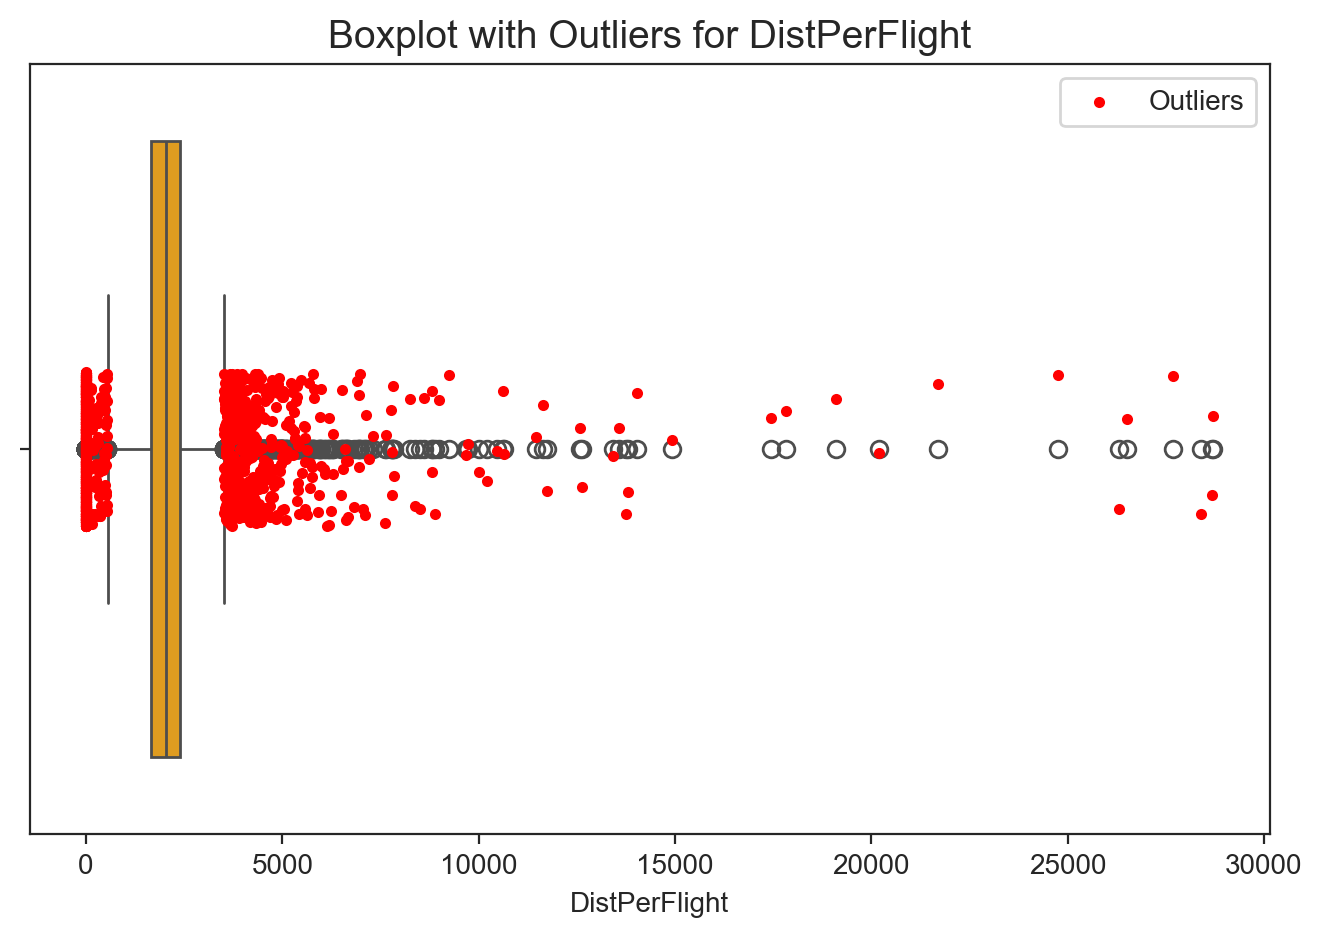

,Column,Num_Outliers,Pct_Outliers
0,Customer Lifetime Value,1460,8.798361
1,Flights_Max,1669,10.057852
2,FlightsComp_Sum,18,0.108473
3,FlightsComp_Mean,18,0.108473
4,DistKM_Max,1808,10.895504
5,PtsRed_Sum,190,1.144992
6,PtsRed_Mean,190,1.144992
7,CostPts_Sum,187,1.126913
8,CostPts_Mean,187,1.126913
9,PointsEfficiency,408,2.458720


In [363]:
detect_outliers_iqr(df_agg_merged[df_agg_merged_out], 0.001)

In [369]:
df_agg_merged.columns

Index(['Loyalty#', 'First Name', 'Last Name', 'Customer Name', 'Country',
       'Province or State', 'City', 'Latitude', 'Longitude', 'Postal code',
       'Gender', 'Education', 'Location Code', 'Income', 'Marital Status',
       'LoyaltyStatus', 'Customer Lifetime Value', 'EnrollmentType',
       'Days_sub', 'Years_Active', 'Months_Active', 'Flights_Sum',
       'Flights_Mean', 'Flights_Max', 'FlightsComp_Sum', 'FlightsComp_Mean',
       'DistKM_Sum', 'DistKM_Mean', 'DistKM_Max', 'PtsAcc_Sum', 'PtsAcc_Mean',
       'PtsRed_Sum', 'PtsRed_Mean', 'CostPts_Sum', 'CostPts_Mean',
       'PointsEfficiency', 'DistPerFlight'],
      dtype='object')

In [371]:
df_agg_merged.loc[df_agg_merged['Customer Lifetime Value']>50000, ['Customer Lifetime Value', 'Income', 'Days_sub', 'Flights_Sum', 'Flights_Mean', 'DistKM_Sum', 'DistKM_Mean', 'PtsAcc_Sum', 'PtsAcc_Mean', 'PtsRed_Sum', 'PtsRed_Mean']]

,Customer Lifetime Value,Income,Days_sub,Flights_Sum,Flights_Mean,DistKM_Sum,DistKM_Mean,PtsAcc_Sum,PtsAcc_Mean,PtsRed_Sum,PtsRed_Mean
4064,51016.07,25167,270,65.0,1.805556,75019.0,2083.861111,7500.00,208.333333,13697.0,380.472222
4065,51016.07,25167,902,124.0,3.647059,491965.9,13665.719444,49188.39,1366.344167,8905.3,247.369444
4066,51426.25,84650,244,15.0,0.416667,71013.0,1972.583333,7100.00,197.222222,0.0,0.000000
4067,52811.49,0,372,49.0,1.361111,88399.0,2455.527778,8838.00,245.500000,4225.0,117.361111
4068,55277.45,40740,68,12.0,0.333333,4104.0,114.000000,410.00,11.388889,0.0,0.000000
4069,56675.94,77237,1366,213.0,6.085714,469220.7,13033.908333,46912.27,1303.118611,35839.3,995.536111
4070,57520.50,48367,331,197.0,5.628571,414025.5,11500.708333,41394.35,1149.843056,10106.2,280.727778
4071,58166.55,61321,1025,129.0,3.685714,250238.3,6951.063889,25016.63,694.906389,9132.0,253.666667
4072,58753.88,24964,851,37.0,1.027778,66859.0,1857.194444,6685.00,185.694444,0.0,0.000000
4073,61850.19,0,2000,111.0,3.171429,231506.5,6430.736111,23146.75,642.965278,0.0,0.000000


<h3>Customers with Flights_Sum == 0 and customer lifetime value > 0

In [386]:
df_agg_merged.loc[(df_agg_merged['Flights_Sum'] == 0) & (df_agg_merged['Customer Lifetime Value'] > 0),
                    ['Customer Lifetime Value', 'Income', 'Days_sub', 'Flights_Sum', 'Flights_Mean', 'DistKM_Sum', 'DistKM_Mean', 'PtsAcc_Sum', 'PtsAcc_Mean', 'PtsRed_Sum', 'PtsRed_Mean']].shape

(1489, 11)

In [388]:
df_agg_merged.loc[(df_agg_merged['Flights_Sum'] == 0) & (df_agg_merged['Customer Lifetime Value'] > 0),
                    ['Customer Lifetime Value', 'Income', 'Days_sub', 'Flights_Sum', 'Flights_Mean', 'DistKM_Sum', 'DistKM_Mean', 'PtsAcc_Sum', 'PtsAcc_Mean', 'PtsRed_Sum', 'PtsRed_Mean']].sample(10)

,Customer Lifetime Value,Income,Days_sub,Flights_Sum,Flights_Mean,DistKM_Sum,DistKM_Mean,PtsAcc_Sum,PtsAcc_Mean,PtsRed_Sum,PtsRed_Mean
6225,5038.98,72919,243,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16006,15700.28,0,316,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13530,5439.36,69186,179,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12231,3693.44,85871,245,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13503,5395.83,70051,163,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14409,7405.42,22044,85,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
207,4272.81,0,845,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7328,6969.88,27604,437,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13757,5737.50,68946,33,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8112,8564.77,23506,2342,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


This doesn't mean that these are errors, this just means that these customers haven't done any flight since joining the loyalty program. To confirm that, we can see that most of them have low number of Days_sub.

## Scaling

MinMax ou Standard???

In [351]:
# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the data and transform it
df_merged_scaled = scaler.fit_transform(df_merged[metric])

# Convert scaled data into a DataFrame with the same index as the original DataFrame
df_merged_scaled_df = pd.DataFrame(df_merged_scaled, columns=metric, index=df_merged.index)

# Select the non-metric features from the original data
non_metric_features = df_merged.drop(columns=metric)

# Combine the scaled metric features with the non-metric features (ensure no new rows are added)
df_combined = pd.concat([df_merged_scaled_df, non_metric_features], axis=1)

In [352]:
df_combined.sample(10)

,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,AvgFlightDistance_month,Income,Customer Lifetime Value,Days_sub,...,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Marital Status,LoyaltyStatus,EnrollmentType
30276,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.487453,0.085507,0.401217,...,Vancouver,49.282730,-123.120740,V6E 3Z3,male,Bachelor,Rural,Married,Nova,Standard
503251,0.333333,0.636364,0.068999,0.068999,0.0,0.0,0.010210,0.000000,0.156502,0.880325,...,Whitehorse,60.721188,-135.056840,Y2K 6R0,female,College,Urban,Single,Nova,Standard
127259,0.380952,0.090909,0.740985,0.740961,0.0,0.0,0.095941,0.176253,0.031440,0.509533,...,Peace River,56.234180,-117.289380,T9O 2W2,female,Master,Rural,Divorced,Star,Standard
570574,0.000000,0.000000,0.318040,0.318040,0.0,0.0,0.000000,0.000000,0.065121,0.701420,...,Whistler,50.116322,-122.957360,V6T 1Y8,female,College,Urban,Married,Aurora,Standard
253977,0.476190,0.000000,0.331018,0.330875,0.0,0.0,0.034288,0.871446,0.072242,0.716024,...,Toronto,43.653225,-79.383186,P1J 8T7,male,Bachelor,Urban,Single,Nova,Standard
369219,0.428571,0.181818,0.586608,0.586584,0.0,0.0,0.067514,0.000000,0.010786,0.849899,...,Montreal,45.501690,-73.567253,H2Y 2W2,female,College,Suburban,Single,Nova,Standard
429790,0.047619,0.090909,0.225728,0.225728,0.0,0.0,0.233815,0.208710,0.010131,0.623935,...,Whistler,50.116322,-122.957360,V6T 1Y8,male,Doctor,Urban,Married,Star,Standard
402068,0.000000,0.000000,0.435357,0.435357,0.0,0.0,0.000000,0.852372,0.092731,0.116024,...,Montreal,45.501690,-73.567253,H2T 2J6,female,Bachelor,Urban,Married,Star,2021 Promotion
428956,0.428571,0.454545,0.376549,0.376549,0.0,0.0,0.043338,0.893020,0.056470,0.506694,...,Trenton,44.101128,-77.576309,K8V 4B2,female,Bachelor,Rural,Married,Nova,Standard
39573,0.571429,0.181818,0.493149,0.493102,0.0,0.0,0.042568,0.375411,0.139081,0.442191,...,Toronto,43.653225,-79.383186,M1R 4K3,male,Bachelor,Suburban,Married,Aurora,Standard


## Missing Values

In [353]:
df_c.isna().sum()

Loyalty#                    0
First Name                  0
Last Name                   0
Customer Name               0
Country                     0
Province or State           0
City                        0
Latitude                    0
Longitude                   0
Postal code                 0
Gender                      0
Education                   0
Location Code               0
Income                     20
Marital Status              0
LoyaltyStatus               0
Customer Lifetime Value    20
EnrollmentType              0
Days_sub                    0
dtype: int64

Missing "CancellationDate" values means that the customer hasn't cancelled the programm yet.

In [354]:
df_f.isna().sum()

Loyalty#                       0
Year                           0
Month                          0
YearMonthDate                  0
NumFlights                  9955
NumFlightsWithCompanions       0
DistanceKM                     0
PointsAccumulated              0
PointsRedeemed                 0
DollarCostPointsRedeemed       0
AvgFlightDistance_month        0
dtype: int64

In [355]:
df_f.sample(10)

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,AvgFlightDistance_month
299614,482169,2020,12,2020-12-01,4.0,0,22127.0,2212.00,0.0,0.0,5531.750000
370350,924719,2020,7,2020-07-01,8.0,8,40334.0,4033.00,0.0,0.0,5041.750000
451826,757127,2019,3,2019-03-01,0.0,0,0.0,0.00,0.0,0.0,0.000000
462713,441359,2019,4,2019-04-01,10.0,1,14183.1,1418.31,0.0,0.0,1418.310000
157373,572547,2021,9,2021-09-01,11.0,0,8124.0,812.00,0.0,0.0,738.545455
85432,124056,2020,1,2020-01-01,9.0,0,16611.0,1661.00,0.0,0.0,1845.666667
391725,140419,2020,7,2020-07-01,0.0,0,0.0,0.00,0.0,0.0,0.000000
329770,195419,2020,10,2020-10-01,0.0,0,0.0,0.00,0.0,0.0,0.000000
552911,741801,2019,9,2019-09-01,NaN,1,21481.2,2148.12,0.0,0.0,21481.200000
431756,591579,2019,2,2019-02-01,0.0,0,0.0,0.00,0.0,0.0,0.000000


We will impute the missing values using the KNN imputer.

In [356]:
imputer = KNNImputer(n_neighbors=5, weights="uniform")

imputer.fit(df_c[c_metric])
df_c[c_metric] = imputer.transform(df_c[c_metric])

In [357]:
df_c.isna().sum()

Loyalty#                   0
First Name                 0
Last Name                  0
Customer Name              0
Country                    0
Province or State          0
City                       0
Latitude                   0
Longitude                  0
Postal code                0
Gender                     0
Education                  0
Location Code              0
Income                     0
Marital Status             0
LoyaltyStatus              0
Customer Lifetime Value    0
EnrollmentType             0
Days_sub                   0
dtype: int64

## Encoding of categorical features